<center><h1><b>ANALYSIS OF CUTS ON MC</b></h1></center>

In this notebook we want to search for the best cuts of the Monte Carlo data

The codes in the pdg are:

$$
\begin{align}
D^0 \rightarrow K^- \quad \pi^+ \\
421 \rightarrow -321 \quad211
\end{align}
$$


$$
\begin{align}
\overline{D^0} \rightarrow& \quad K^+ \qquad \pi^- \\
-421 \rightarrow& +321 \quad-211
\end{align}
$$

In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline

import gc
import itertools
import os
import glob

# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

---

# UPLOADING DATA

#### ALL OUR DATA

In [2]:
# %%bash
# ls "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"

#### UPLOAD DATA
Let's upload the data while:
* ignoring useless columns ("neg_pt", "pos_pt")
* substituting (or rather summarizing them) the columns of MC info with a single column telling us who is D0 (1), who anti-D0 (-1) and who background (0)

In [3]:
# directory where the files are stored
folder = "/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs"
all_files = glob.glob(os.path.join(folder, "*.pkl"))
# choose eventually which columns to exclude:
useless_cols = ["neg_pt", "pos_pt"]

# choose how many files to load
x = 48                              # change this to the number of files you want (or your RAM can afford..)
files_to_load = all_files[:x]

print(f"Found {len(all_files)} files. Loading up to {len(files_to_load)} files")

Found 57 files. Loading up to 48 files


In [4]:
# initialization
final_results = pd.DataFrame()

# UPLOAD ---------------------------------------------------------------------
for i, f in enumerate(files_to_load, start=1):
    
    # UPLOAD DATA excluding useless columns:
    df = pd.read_pickle(f)
    df = df.drop(columns=useless_cols)

    # DEFINING MASKS to decrease the number of columns by summarizing them:
    mask_true_d0 = (
        (df["track_pdg_pos"] == 211 ) &
        (df["track_pdg_neg"] == -321 ) &
        (df["mother_pdg_pos"] == 421) &
        (df["mother_pdg_neg"] == 421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2)
    )
    mask_true_anti_d0 = (
        (df["track_pdg_pos"] == 321) &
        (df["track_pdg_neg"] == -211) &
        (df["mother_pdg_pos"] == -421) &
        (df["mother_pdg_neg"] == -421) &
        (df["beauty_pdg_pos"] == 0) &
        (df["beauty_pdg_neg"] == 0) &
        (df["mother_N_final_state_pos"] == 2) &
        (df["mother_N_final_state_neg"] == 2)
    )
    mask_background = ( (~mask_true_d0) & (~mask_true_anti_d0) )

    # SUMMARIZE some columns:
    df["truth"] = np.select( [mask_true_d0, mask_true_anti_d0] , [1, -1], default=0)
    summarized_cols = ["track_pdg_pos", "track_pdg_neg", "mother_pdg_pos", "mother_pdg_neg", "beauty_pdg_pos", "beauty_pdg_neg",
                     "mother_N_final_state_pos", "mother_N_final_state_neg"]
    df = df.drop(columns=summarized_cols)

    # FINAL single file uploaded:
    final_results = pd.concat([final_results, df], ignore_index=True)
    
    # free memory
    del df
    gc.collect()
    
    # debug
    print(f"{i}", end=' ')

print(f"\nFinished: loaded {i} files out of {len(all_files)} available.")

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 
Finished: loaded 48 files out of 57 available.


In [5]:
print(f"The uploaded dataframe has {len(final_results):_} rows and {len(final_results.columns):_} columns.")
memory = final_results.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([final_results.head(5),final_results.tail(5)]) )

The uploaded dataframe has 42_078_178 rows and 19 columns.
It occupies 6_099.59 MB in RAM memory


,dcaXY_product,inv_mass,anti_mass,pt,decay_length,cos_pointing,neg_TPCka,neg_TOFka,neg_fDcaXY,pos_TPCpi,pos_TOFpi,pos_fDcaXY,neg_TPCpi,neg_TOFpi,pos_TPCka,pos_TOFka,mother_orig_ind_pos,mother_orig_ind_neg,truth
0,-0.001307,1.647857,1.449501,1.590537,2.064567,0.378364,-6.947757,133.719315,-0.093189,-1.825205,6352.559082,0.014020,0.260088,951.748230,-0.417602,587.019836,9618.0,-1.0,0
1,-0.007081,0.947897,0.935076,0.698830,5.386100,-0.238735,-6.947757,133.719315,-0.093189,-0.913118,-1072.173340,0.075984,0.260088,951.748230,-6.905696,-147.886261,-1.0,-1.0,0
2,0.005584,0.813485,0.819674,0.772823,3.091237,0.265503,-6.947757,133.719315,-0.093189,1.178568,-999.000000,-0.059924,0.260088,951.748230,-6.446581,-999.000000,-1.0,-1.0,0
3,-0.016409,0.966982,0.953821,0.597828,3.955609,-0.544734,-6.947757,133.719315,-0.093189,69.200188,-999.000000,0.176080,0.260088,951.748230,24.368649,-999.000000,-1.0,-1.0,0
4,0.015970,1.400717,1.328300,0.452560,3.330226,0.408916,-6.947757,133.719315,-0.093189,-0.713104,-999.000000,-0.171371,0.260088,951.748230,-2.782018,-999.000000,-1.0,-1.0,0
42078173,0.000018,1.137063,1.121761,0.434827,0.031667,-0.406751,-6.202718,-999.000000,0.000677,52.309784,-999.000000,0.026365,0.156691,-999.000000,22.910799,-999.000000,-1.0,-1.0,0
42078174,-0.000008,1.044572,0.800734,2.370529,0.014667,0.927076,-2.227919,-22.389658,0.004341,-3.439414,-999.000000,-0.001915,-0.632328,1.465962,-1.839460,-999.000000,-1.0,-1.0,0
42078175,-0.000029,1.087169,1.124374,0.515417,0.012695,0.258485,18.927122,-999.000000,-0.009719,0.150032,1.439656,0.003020,32.800396,-999.000000,-5.904624,-39.326065,-1.0,-1.0,0
42078176,0.000016,2.317238,2.257028,0.593064,0.112831,0.991632,-3.387855,-29.143049,-0.008147,-0.539399,-999.000000,-0.001947,-0.985466,-1.259221,0.379039,-999.000000,-1.0,-1.0,0
42078177,-0.000022,1.280191,1.045324,1.280705,0.016345,-0.997064,-8.850271,-999.000000,0.011160,-0.539399,-999.000000,-0.001947,0.801999,-999.000000,0.379039,-999.000000,-1.0,-1.0,0


---

## TRUE $D_0$ IN OUR DATA

In [6]:
# let's define the masks for the MC info on TRUE D0 and anti-D0:
mask_true_d0 = ( final_results["truth"] == 1 )
mask_true_anti_d0 = ( final_results["truth"] == -1 )
mask_signal = ( (mask_true_d0) | (mask_true_anti_d0) )
mask_background = ( final_results["truth"] == 0 )

In [25]:
d0_tot = np.sum( mask_true_d0 )
anti_d0_tot = np.sum( mask_true_anti_d0 )
signal_tot = d0_tot + anti_d0_tot
num_bg_pairs = np.sum( mask_background )
print("Number of D0:      ", d0_tot )
print("Number of anti-D0: ", anti_d0_tot )
print(f"Number of background pairs: {num_bg_pairs:_}")
print(f"Fraction of D0 and anti-D0 over total: {(d0_tot+anti_d0_tot)/len(final_results) * 100:.4f}%"  )

Number of D0:       8243
Number of anti-D0:  8671
Number of background pairs: 42_061_264
Fraction of D0 and anti-D0 over total: 0.0402%


The variables we have to work with are:

In [8]:
print(final_results.columns)

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'neg_TPCka', 'neg_TOFka', 'neg_fDcaXY', 'pos_TPCpi',
       'pos_TOFpi', 'pos_fDcaXY', 'neg_TPCpi', 'neg_TOFpi', 'pos_TPCka',
       'pos_TOFka', 'mother_orig_ind_pos', 'mother_orig_ind_neg', 'truth'],
      dtype='object')


Example: the variable 'neg_TOFka' refers to the TOF in the Kaon hypothesis, i.e. the time of flight expressed in how many sigma we are away from the mean of the typical Kaon flight. The 'neg' refers to the fact that this is measured for the negative track particle, which is a $K^-$ for the $D^0$ case, a $\pi^-$ for the $anti-D^0$ case, and something else in background case.

In [9]:
# final_results.to_csv("/home/benedetto/Scrivania/LCP_B/project/df_pairs_all_variabs/giga_chunk_1.csv", index=False)

---

---

# INVARIANT MASS PLOT
We now plot the data, remembering to plot both the columns for mass and anti-mass because we want to include the reflex component.

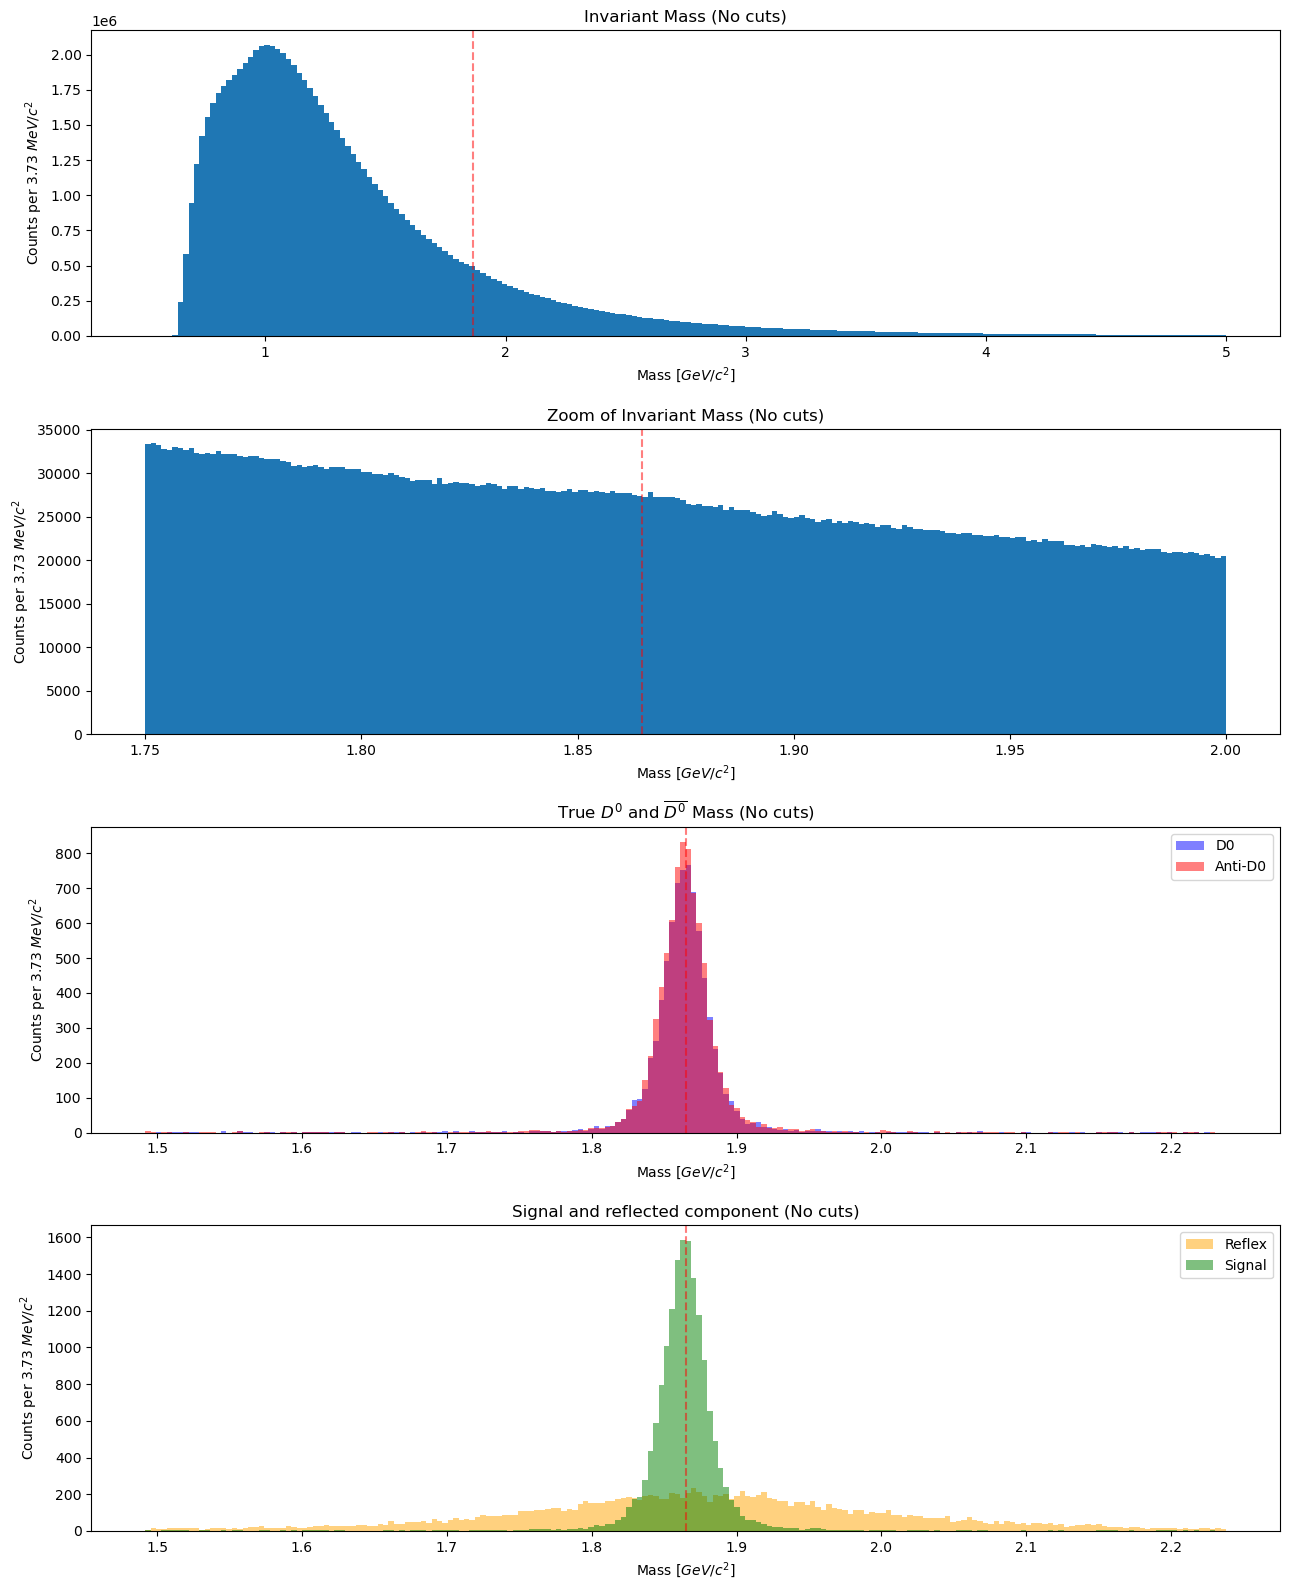

In [10]:
MIN_MASS, MAX_MASS = 0.80*m_d0, 1.20*m_d0
N_BINS = 200

num_of_plots = 4
fig, axs = plt.subplots( num_of_plots, 1, figsize=(13,4*num_of_plots)  )

# GLOBAL PLOT ---------------------------------------- 
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values])
axs[0].hist( data, bins=N_BINS, range=(0.5, 5))
axs[0].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[0].set_xlabel("Mass [$GeV/c^2$]")
axs[0].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[0].set_title("Invariant Mass (No cuts)")
#axs[0].set_xticks( np.arange(0, 8) )

# ZOOM OF GLOBAL PLOT ---------------------------------------- 
data = np.concatenate( [final_results["inv_mass"].values, final_results["anti_mass"].values] )
axs[1].hist( data, bins=N_BINS, range=(1.75, 2))
axs[1].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[1].set_xlabel("Mass [$GeV/c^2$]")
axs[1].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[1].set_title("Zoom of Invariant Mass (No cuts)")
#axs[1].set_xticks( np.arange(0, 8) )

# PLOTTING TRUE D0 and TRUE anti-D0 FROM MC INFO ---------------------------------------- 
data = final_results.loc[mask_true_d0, "inv_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="blue", alpha=0.5, label="D0")
data = final_results.loc[mask_true_anti_d0, "anti_mass"].values
axs[2].hist( data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="red", alpha=0.5, label="Anti-D0")
axs[2].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[2].set_xlabel("Mass [$GeV/c^2$]")
axs[2].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[2].set_title(r"True $D^0$ and $\overline{{D^0}}$ Mass (No cuts)")
axs[2].legend()
#axs[2].set_xticks( np.arange(1.6, 2.2, 0.05) )

#  ---------------------------------------- 
# PLOTTING signal (D0 mass + anti-D0 anti-mass) reflex component (D0 anti-mass + anti-D0 mass)
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
axs[3].hist( reflex_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="orange", alpha=0.5, label="Reflex")
axs[3].hist( signal_data , bins=N_BINS, range=(MIN_MASS, MAX_MASS), color="green", alpha=0.5, label="Signal")
axs[3].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs[3].set_xlabel("Mass [$GeV/c^2$]")
axs[3].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs[3].set_title(r"Signal and reflected component (No cuts)")
axs[3].legend()



del data
#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

From the plot above we can see that the width of the mass peak is around $1.80-1.93$ $MeV/c^2$. So during the search for the $D_0$ in real data we can focus in this interval.  

Also the distribution of $D_0$ and $anti-D_0$ is almost the same.

---

---

# VARIABLES DISTRIBUTION
Let's study the distribution of the variables for the known correct tracks. In this way we can do better cuts.

### $\pi^+$ TRACKS
Let's observe the distribution of the variables for the $\pi^+$ tracks, for both the known $D_0$ and also for all the combinatory background.

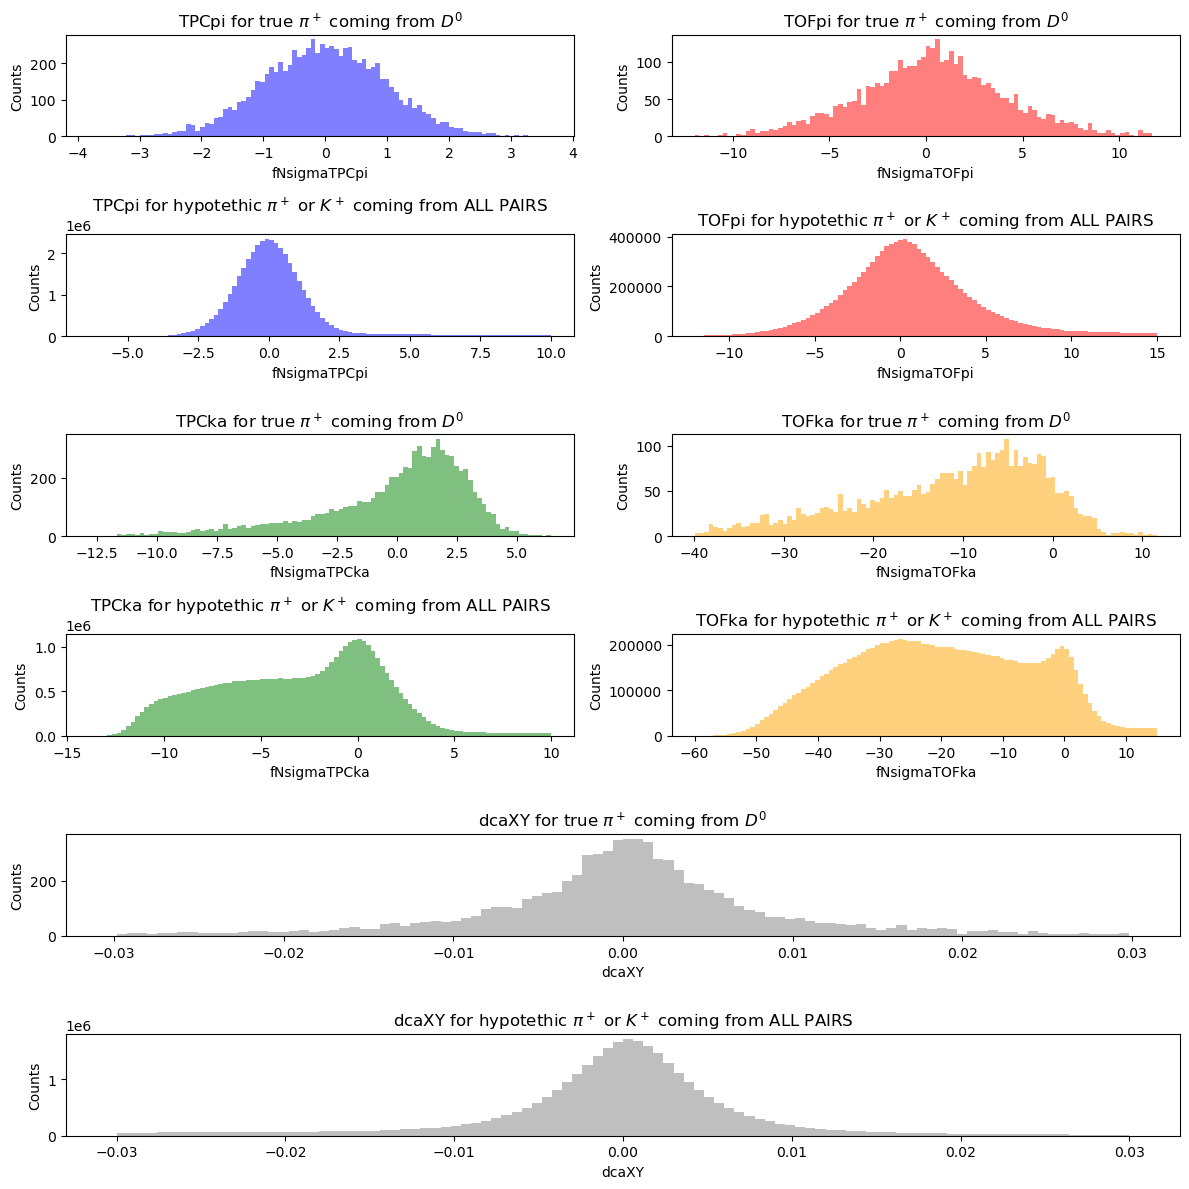

In [11]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_D0", "tofpi_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_D0", "tofka_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 12)
)

# --- Plot TPCpi for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TPCpi'].values
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_D0"].set_title(r"TPCpi for true $\pi^+$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for true $\pi^+$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS---
data = final_results['pos_TPCpi'].values
data = data[(data > -7) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['pos_TOFpi'].values
data = data[(data > -12) & (data < 15)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot TPCka for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_D0"].set_title(r"TPCka for true $\pi^+$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_TOFka'].values
data = data[(data > -40) & (data < 12)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for true $\pi^+$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS ---
data = final_results['pos_TPCka'].values
data = data[(data > -20) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['pos_TOFka'].values
data = data[(data > -60) & (data < 15)]
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot dcaXY for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="grey", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for true $\pi^+$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['pos_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="grey", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $\pi^+$ or $K^+$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $\pi^-$ TRACKS
Let's observe the distribution of the variables for the $\pi^-$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

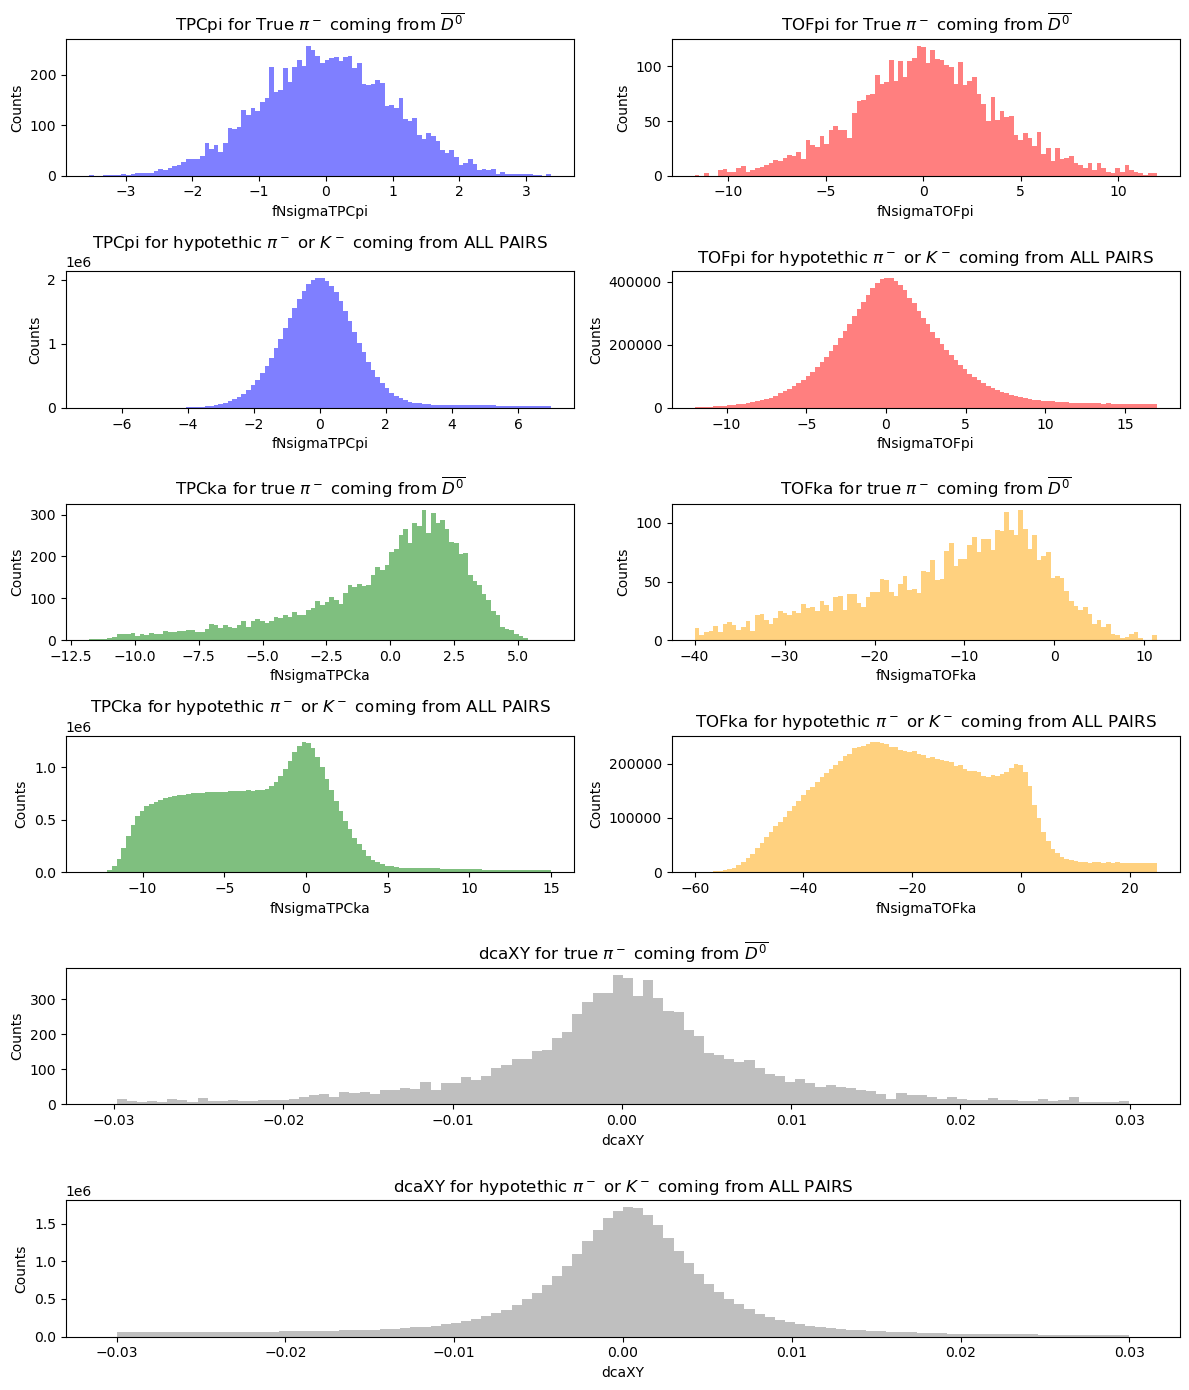

In [12]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["tpcpi_anti_D0", "tofpi_anti_D0"],
    ["tpcpi_all", "tofpi_all"],
    ["tpcka_anti_D0", "tofka_anti_D0"],
    ["tpcka_all", "tofka_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 14)
)

# --- Plot TPCpi for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TPCpi'].values
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_anti_D0"].set_title(r"TPCpi for True $\pi^-$ coming from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TOFpi'].values
data = data[(data > -12) & (data < 12)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for True $\pi^-$ coming from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS---
data = final_results['neg_TPCpi'].values
data = data[(data > -7) & (data < 7)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['neg_TOFpi'].values
data = data[(data > -12) & (data < 17)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TPCka for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_anti_D0"].set_title(r"TPCka for true $\pi^-$ coming from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_TOFka'].values
data = data[(data > -40) & (data < 12)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for true $\pi^-$ coming from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS ---
data = final_results['neg_TPCka'].values
data = data[(data > -20) & (data < 15)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka con filtro (-12, 12) FOR ALL PAIRS ---
data = final_results['neg_TOFka'].values
data = data[(data > -60) & (data < 25)]
axes["tofka_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")


# --- Plot dcaXY for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'neg_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $\pi^-$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['neg_fDcaXY'].values
data = data[(data > -0.03) & (data < 0.03)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $\pi^-$ or $K^-$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()

del data


### $K^-$ TRACKS
Let's observe the distribution of the variables for the $Kaons^-$ tracks, for both the known $D_0$ and also for all the combinatory background.

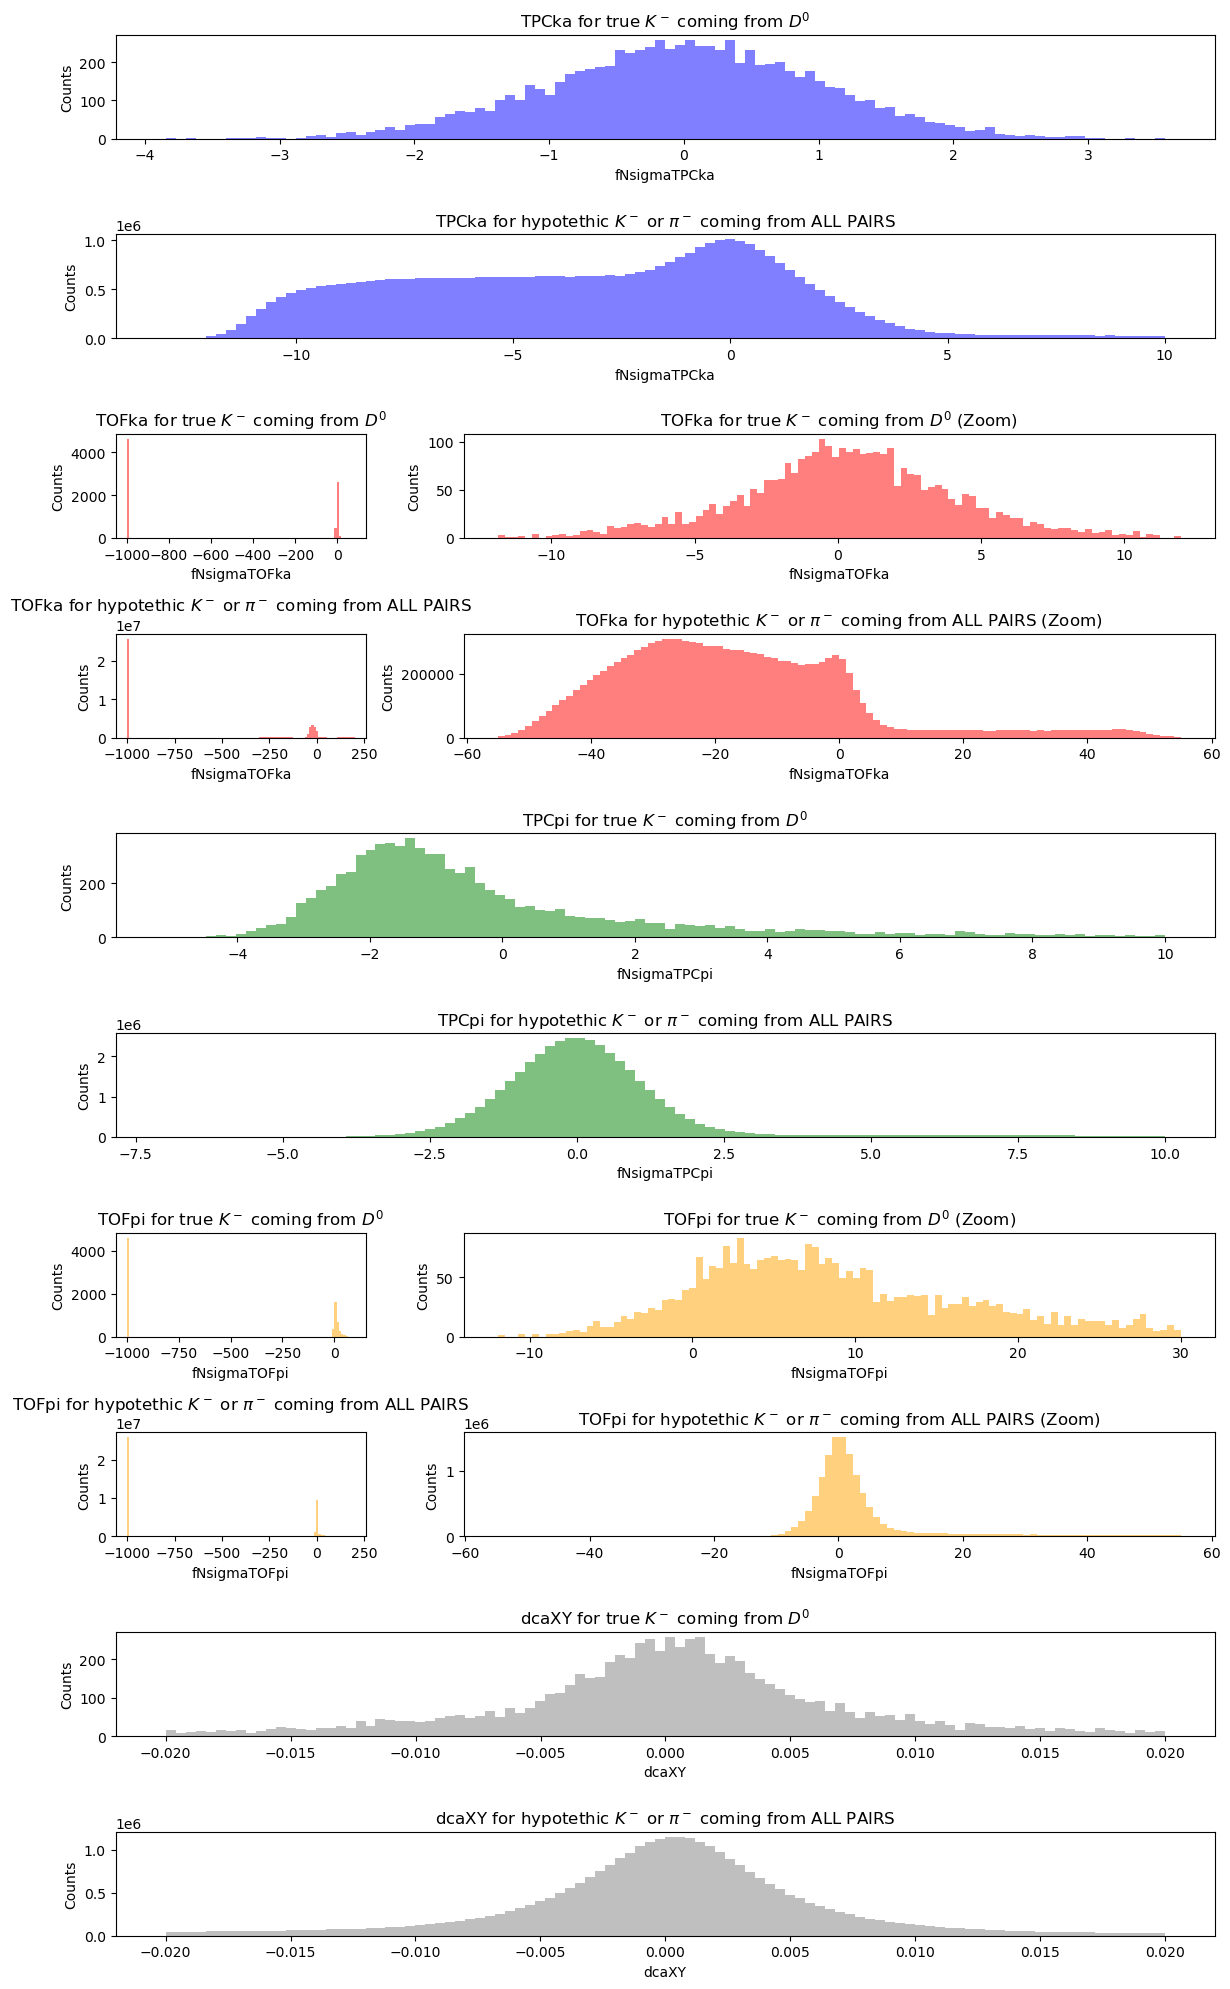

In [13]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_D0", "tpcka_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_D0", "tofka_zoom_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_D0", "tpcpi_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_D0", "tofpi_zoom_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_D0","dcaxy_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE D0---
data = final_results.loc[mask_true_d0, 'neg_TPCka'].values
axes["tpcka_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_D0"].set_title(r"TPCka for true $K^-$ coming from $D^0$")
axes["tpcka_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS---
data = final_results['neg_TPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$")
axes["tofka_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_D0"].set_title(r"TOFka for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofka_zoom_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR ALL PAIRS ---
data = final_results['neg_TOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot TPCpi FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TPCpi'].values
data = data[ data < 10 ]
axes["tpcpi_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_D0"].set_title(r"TPCpi for true $K^-$ coming from $D^0$")
axes["tpcpi_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS ---
data = final_results['neg_TPCpi'].values
data = data[(data > -13) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_TOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$")
axes["tofpi_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_D0"].set_ylabel("Counts")

# --- Plot TOFpi zoom (-12,12) FOR TRUE D0 ---
data_zoom = data[(data > -12) & (data < 30)]
axes["tofpi_zoom_D0"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_D0"].set_title(r"TOFpi for true $K^-$ coming from $D^0$ (Zoom)")
axes["tofpi_zoom_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_D0"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR ALL PAIRS ---
data = final_results['neg_TOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TOFpi zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofpi_zoom_all"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_all"].set_title(r"TOFpi for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")
#-------------------------------------------------------------------

# --- Plot dcaXY FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_D0"].set_title(r"dcaXY for true $K^-$ coming from $D^0$")
axes["dcaxy_D0"].set_xlabel("dcaXY")
axes["dcaxy_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['neg_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $K^-$ or $\pi^-$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

### $K^+$ TRACKS
Let's observe the distribution of the variables for the $Kaons^+$ tracks, for both the known $anti-D_0$ and also for all the combinatory background.

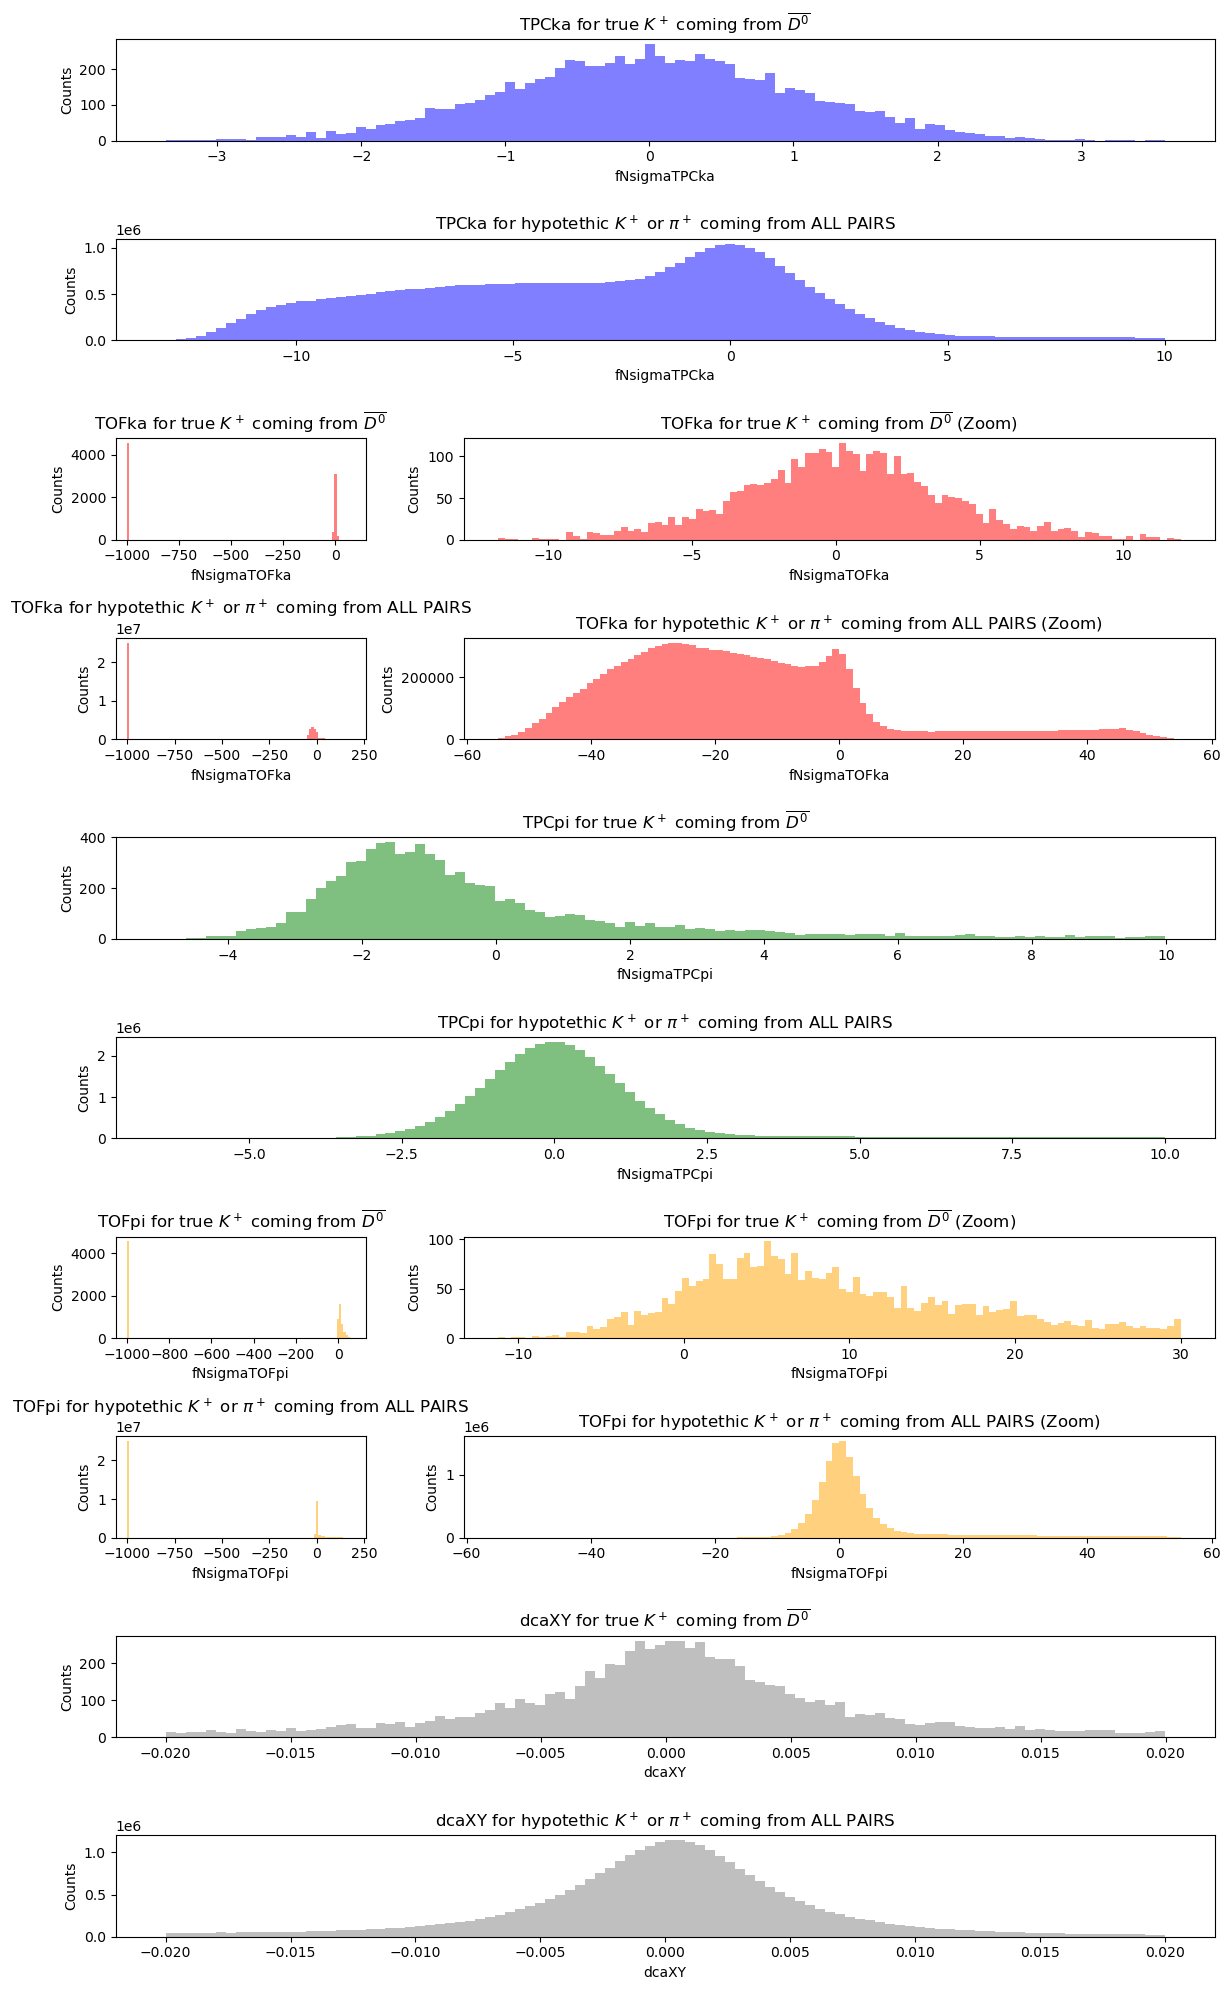

In [14]:
N_BINS = 100

# zones for the plots:
zones = [
    ["tpcka_anti_D0", "tpcka_anti_D0"],
    ["tpcka_all", "tpcka_all"],
    ["tofka_anti_D0", "tofka_zoom_anti_D0"],
    ["tofka_all", "tofka_zoom_all"],
    ["tpcpi_anti_D0", "tpcpi_anti_D0"],
    ["tpcpi_all", "tpcpi_all"],
    ["tofpi_anti_D0", "tofpi_zoom_anti_D0"],
    ["tofpi_all", "tofpi_zoom_all"],
    ["dcaxy_anti_D0","dcaxy_anti_D0"],
    ["dcaxy_all","dcaxy_all"]
]

# Creazione della figura con proporzioni personalizzate
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 20),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot TPCka FOR TRUE anti_D0---
data = final_results.loc[mask_true_anti_d0, 'pos_TPCka'].values
axes["tpcka_anti_D0"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_anti_D0"].set_title(r"TPCka for true $K^+$ coming from $\overline{D^0}$")
axes["tpcka_anti_D0"].set_xlabel("fNsigmaTPCka")
axes["tpcka_anti_D0"].set_ylabel("Counts")

# --- Plot TPCka FOR ALL PAIRS---
data = final_results['pos_TPCka'].values
data = data[(data > -13) & (data < 10)]
axes["tpcka_all"].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axes["tpcka_all"].set_title(r"TPCka for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tpcka_all"].set_xlabel("fNsigmaTPCka")
axes["tpcka_all"].set_ylabel("Counts")

# --- Plot TOFka completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_TOFka'].values
data = data[(data > -1000) & (data < 100)]
axes["tofka_anti_D0"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$")
axes["tofka_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka zoom (-12,12) FOR TRUE anti_D0 ---
data_zoom = data[(data > -12) & (data < 12)]
axes["tofka_zoom_anti_D0"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_anti_D0"].set_title(r"TOFka for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofka_zoom_anti_D0"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFka completo FOR ALL PAIRS ---
data = final_results['pos_TOFka'].values
data = data[(data > -1000) & (data < 200)]
axes["tofka_all"].hist(data, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_all"].set_title(r"TOFka for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tofka_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_all"].set_ylabel("Counts")

# --- Plot TOFka zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofka_zoom_all"].hist(data_zoom, bins=N_BINS, color="red", alpha=0.5)
axes["tofka_zoom_all"].set_title(r"TOFka for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS (Zoom)")
axes["tofka_zoom_all"].set_xlabel("fNsigmaTOFka")
axes["tofka_zoom_all"].set_ylabel("Counts")
#-------------------------------------------------------------------

# --- Plot TPCpi FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_TPCpi'].values
data = data[ data < 10 ]
axes["tpcpi_anti_D0"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_anti_D0"].set_title(r"TPCpi for true $K^+$ coming from $\overline{D^0}$")
axes["tpcpi_anti_D0"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_anti_D0"].set_ylabel("Counts")

# --- Plot TPCpi FOR ALL PAIRS ---
data = final_results['pos_TPCpi'].values
data = data[(data > -13) & (data < 10)]
axes["tpcpi_all"].hist(data, bins=N_BINS, color="green", alpha=0.5)
axes["tpcpi_all"].set_title(r"TPCpi for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tpcpi_all"].set_xlabel("fNsigmaTPCpi")
axes["tpcpi_all"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_TOFpi'].values
data = data[(data > -1000) & (data < 100)]
axes["tofpi_anti_D0"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$")
axes["tofpi_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi zoom (-12,12) FOR TRUE anti_D0 ---
data_zoom = data[(data > -12) & (data < 30)]
axes["tofpi_zoom_anti_D0"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_anti_D0"].set_title(r"TOFpi for true $K^+$ coming from $\overline{D^0}$ (Zoom)")
axes["tofpi_zoom_anti_D0"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_anti_D0"].set_ylabel("Counts")

# --- Plot TOFpi completo FOR ALL PAIRS ---
data = final_results['pos_TOFpi'].values
data = data[(data > -1000) & (data < 200)]
axes["tofpi_all"].hist(data, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_all"].set_title(r"TOFpi for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["tofpi_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_all"].set_ylabel("Counts")

# --- Plot TOFpi zoom FOR ALL PAIRS ---
data_zoom = data[(data > -55) & (data < 55)]
axes["tofpi_zoom_all"].hist(data_zoom, bins=N_BINS, color="orange", alpha=0.5)
axes["tofpi_zoom_all"].set_title(r"TOFpi for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS (Zoom)")
axes["tofpi_zoom_all"].set_xlabel("fNsigmaTOFpi")
axes["tofpi_zoom_all"].set_ylabel("Counts")

#-------------------------------------------------------------------
# --- Plot dcaXY FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pos_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_anti_D0"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_anti_D0"].set_title(r"dcaXY for true $K^+$ coming from $\overline{D^0}$")
axes["dcaxy_anti_D0"].set_xlabel("dcaXY")
axes["dcaxy_anti_D0"].set_ylabel("Counts")

# --- Plot dcaXY FOR ALL PAIRS ---
data = final_results['pos_fDcaXY'].values
data = data[(data > -0.02) & (data < 0.02)]
axes["dcaxy_all"].hist(data, bins=N_BINS, color="gray", alpha=0.5)
axes["dcaxy_all"].set_title(r"dcaXY for hypotethic $K^+$ or $\pi^+$ coming from ALL PAIRS")
axes["dcaxy_all"].set_xlabel("dcaXY")
axes["dcaxy_all"].set_ylabel("Counts")

plt.tight_layout()
plt.show()
del data

We can see that the variables TPCka and TOFka can be very useful as cuts. 

But what to do with data at -999 TOF? Let's see.

In [15]:
print(f"Total number of D0s: {d0_tot}")
data = final_results.loc[mask_true_d0, 'neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True D0s with TOFka = -999:       {len(data)/d0_tot:.2f}")
print(f"Fraction of True D0s with TOFka != -999: :    { (d0_tot-len(data)) / d0_tot :.2f} \n")

print(f"Total number of antiD0s: {anti_d0_tot}")
data = final_results.loc[mask_true_anti_d0, 'neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of True anti_D0s with TOFka = -999:  {len(data)/anti_d0_tot:.2f}")
print(f"Fraction of True anti_D0s with TOFka != -999: { (anti_d0_tot-len(data)) / anti_d0_tot :.2f} \n")

print(f"Total number of data: {len(final_results)}")
data = final_results['neg_TOFka'].values
data = data[ (data > -1000) & (data < -998)]
print(f"Fraction of all data with TOFka = -999:  :    {len(data)/len(final_results) :.2f}")
print(f"Fraction of all data with TOFka != -999: :    { (len(final_results)-len(data)) / len(final_results) :.2f}")
del data

Total number of D0s: 8243
Fraction of True D0s with TOFka = -999:       0.56
Fraction of True D0s with TOFka != -999: :    0.44 

Total number of antiD0s: 8671
Fraction of True anti_D0s with TOFka = -999:  0.48
Fraction of True anti_D0s with TOFka != -999: 0.52 

Total number of data: 42078178
Fraction of all data with TOFka = -999:  :    0.61
Fraction of all data with TOFka != -999: :    0.39


If we keep the data with TOFka=-999, we keep a lot of background.  
Instead if we remove it, yeah we lose 44% of true D0, but we stay in a zone where our cuts are very effective (see plot above). So cutting away TOFka=-999 could be a good choice.

### SEARCH FOR BEST CUTS
Let's search for best cuts over the variables ['neg_TOFka', 'neg_TPCka', 'pos_TOFka', 'pos_TPCka'], appeared to be the best choices from previous plots.

Migliori cuts trovati all'ultima run (da verificare):
```
Best cuts found:
neg_TOFka: ±7.25
neg_TPCka: ±1.97
pos_TOFka: ±7.83
pos_TPCka: ±1.83
Maximum significance S/√(S+B): 5.301
```

In [24]:
# decide if searching in this run of the notebook:
search = "no"


# --- DATA ---
signal_data = final_results.loc[ 
                    mask_signal & (final_results['cos_pointing'] > 0.96) & ((final_results['pt'] > 2) & (final_results['pt'] < 8)), # rows
                    ['neg_TOFka', 'neg_TPCka', 'pos_TOFka', 'pos_TPCka']]                                                           # columns
background_data = final_results.loc[
                    mask_background  & (final_results['cos_pointing'] > 0.96) & ((final_results['pt'] > 2) & (final_results['pt'] < 8)), # rows
                    ['neg_TOFka', 'neg_TPCka', 'pos_TOFka', 'pos_TPCka']]                                                                # columns

# --- DEFINE CANDIDATE CUTS ---
neg_TOFka_cuts = np.linspace(6.8, 7.7, 7)   # example thresholds
neg_TPCka_cuts = np.linspace(1.8, 2.3, 7)
pos_TOFka_cuts = np.linspace(7.5, 8.5, 7)
pos_TPCka_cuts = np.linspace(1.5, 2.5, 7)

# --- VARIABLES ---
total_iterations = len(neg_TOFka_cuts) * len(neg_TPCka_cuts) * len(pos_TOFka_cuts) * len(pos_TPCka_cuts)
iteration = 0
best_significance = 0
best_cuts = {}


# --- GRID SEARCH ---
if search=="yes":
    for neg_TOF in neg_TOFka_cuts:
        for neg_TPC in neg_TPCka_cuts:
            for pos_TOF in pos_TOFka_cuts:
                for pos_TPC in pos_TPCka_cuts:
    
                    # debug:
                    iteration += 1
                    if iteration % 50 == 0 or iteration == 1:    # print progress every 50 iterations
                        print(f"{iteration}/{total_iterations}", end=' ')
                    
                    # define rectangular PID cut
                    signal_pass = (
                        ( (signal_data['neg_TOFka'] > -neg_TOF) & (signal_data['neg_TOFka'] < neg_TOF) &
                          (signal_data['neg_TPCka'] > -neg_TPC) & (signal_data['neg_TPCka'] < neg_TPC) )
                        |
                        ( (signal_data['pos_TOFka'] > -pos_TOF) & (signal_data['pos_TOFka'] < pos_TOF) &
                          (signal_data['pos_TPCka'] > -pos_TPC) & (signal_data['pos_TPCka'] < pos_TPC) )
                    )
                    background_pass = (
                        ( (background_data['neg_TOFka'] > -neg_TOF) & (background_data['neg_TOFka'] < neg_TOF) &
                          (background_data['neg_TPCka'] > -neg_TPC) & (background_data['neg_TPCka'] < neg_TPC) )
                        |
                        ( (background_data['pos_TOFka'] > -pos_TOF) & (background_data['pos_TOFka'] < pos_TOF) &
                          (background_data['pos_TPCka'] > -pos_TPC) & (background_data['pos_TPCka'] < pos_TPC) )
                    )
    
                    s = signal_pass.sum()
                    b = background_pass.sum()
    
                    if s + b > 0:
                        significance = s / np.sqrt(s + b)
                        if significance > best_significance:
                            best_significance = significance
                            best_cuts = {
                                'neg_TOFka': neg_TOF,
                                'neg_TPCka': neg_TPC,
                                'pos_TOFka': pos_TOF,
                                'pos_TPCka': pos_TPC
                            }

# --- RESULTS ---
if search=="yes":
    print('')
    print("Best cuts found:")
    for k, v in best_cuts.items():
        print(f"{k}: ±{v:.2f}")
    print(f"Maximum significance S/√(S+B): {best_significance:.3f}")

---

# PAIR VARIABLES

### POYNTING ANGLE

With the cut at 0.95 we cut off 58.29% of original D0s
With the cut at 0.95 we cut off 57.24% of original anti-D0s
With the cut at 0.95 we cut off 91.81% of background pairs


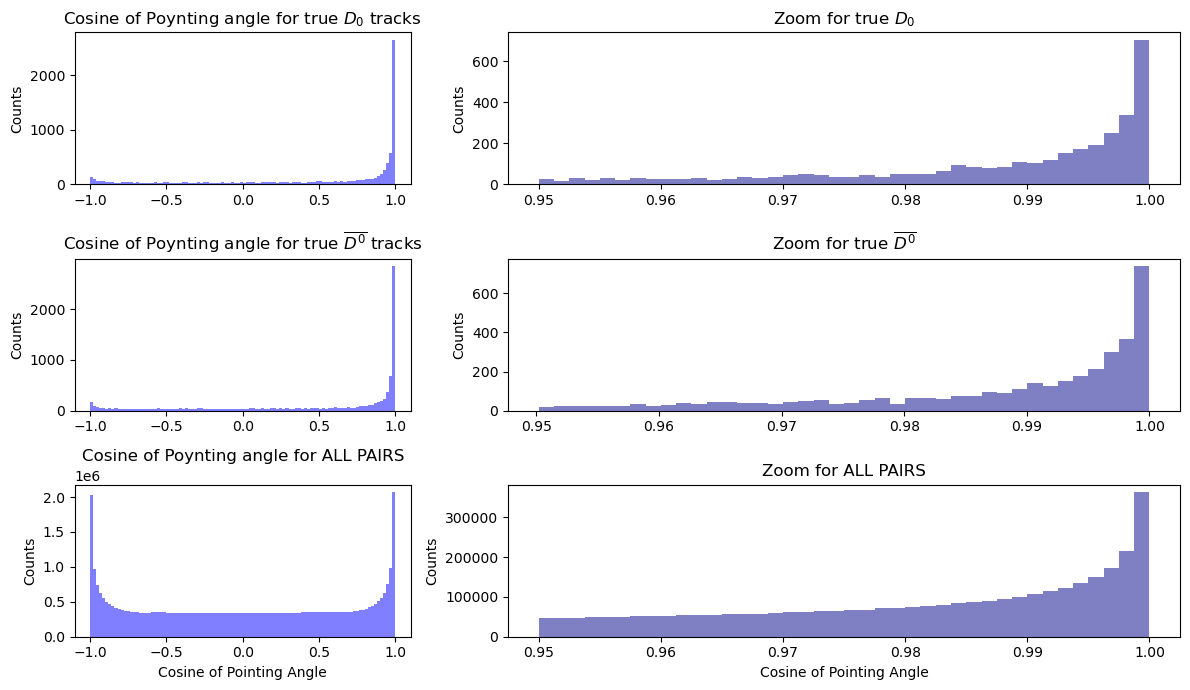

In [17]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_anti_D0", "zoom_anti_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 7),
    gridspec_kw={"width_ratios": [1, 2]}
)

# --- Plot cosine of poynting angle FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'cos_pointing'].values
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("Cosine of Poynting angle for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom for true $D_0$")

print(f"With the cut at {cut} we cut off {100-len(data)/d0_tot*100:.2f}% of original D0s")

# --- Plot cosine of poynting angle FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'cos_pointing'].values
axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_anti_D0"].set_ylabel("Counts")
axes["total_anti_D0"].set_title(r"Cosine of Poynting angle for true $\overline{D^0}$ tracks")

# --- Zoom FOR TRUE anti_D0 ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_anti_D0"].hist( data, bins=40, color="darkblue", alpha=0.5)
axes["zoom_anti_D0"].set_ylabel("Counts")
axes["zoom_anti_D0"].set_title("Zoom for true $\overline{D^0}$")

print(f"With the cut at {cut} we cut off {100-len(data)/anti_d0_tot*100:.2f}% of original anti-D0s")

# --- Plot cosine of poynting angle FOR ALL PAIRS ---
data = final_results['cos_pointing'].values
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("Cosine of Pointing Angle")
axes["total_all"].set_title("Cosine of Poynting angle for ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.95
data = data[ data > cut ]
axes["zoom_all"].hist( data, bins=40, color="darkblue", alpha=0.5)
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("Cosine of Pointing Angle")
axes["zoom_all"].set_title("Zoom for ALL PAIRS")

print(f"With the cut at {cut} we cut off {100-len(data)/num_bg_pairs*100:.2f}% of background pairs")

plt.tight_layout()
plt.show()

del data

Best cut: cos(pointing) > 0.9636
With the cut at 0.96 we cut off 61.06% of original signal
With the cut at 0.96 we cut off 93.13% of background pairs


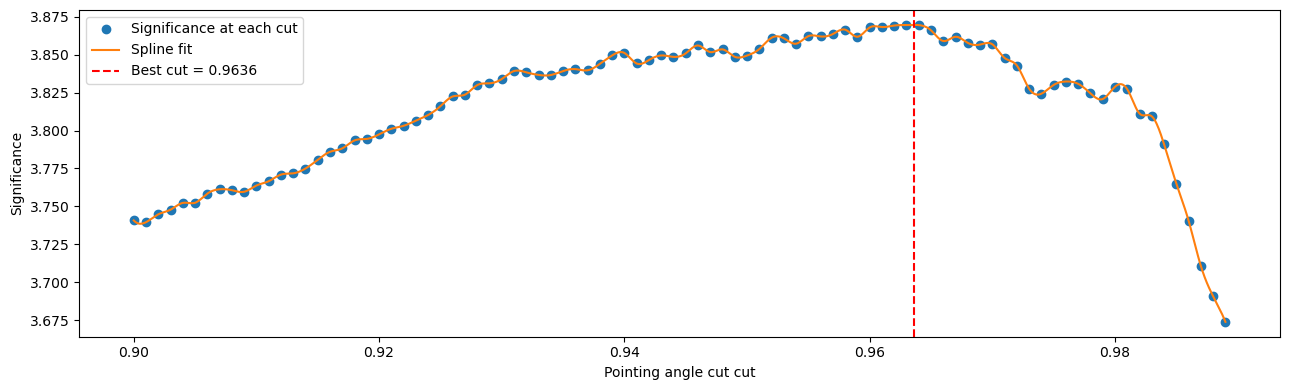

In [18]:
# SEARCH FOR BEST CUT IN POYNTING ANGLE:
x_val = np.arange(0.9, 0.99, 0.001)
y_val =[]

signal_pointing = final_results.loc[ mask_signal, 'cos_pointing'].values
background_pointing = final_results.loc[ mask_background, 'cos_pointing'].values

for x in x_val:
    numerator = len( signal_pointing[ signal_pointing>x ] )
    denominator = len( background_pointing[ background_pointing>x ] )
    y_val.append(numerator / np.sqrt(numerator + denominator))

# INTERPOLATION with spline:
spline = UnivariateSpline(x_val, y_val, s=0)
x_dense = np.linspace(min(x_val), max(x_val), 1000)
y_dense = spline(x_dense)               # computating the spline
best_cut = x_dense[np.argmax(y_dense)]

# PRINT results:
print(f"Best cut: cos(pointing) > {best_cut:.4f}")
print(f"With the cut at {best_cut:.2f} we cut off {100-len( signal_pointing[ signal_pointing>best_cut ] )/signal_tot*100:.2f}% of original signal")
print(f"With the cut at {best_cut:.2f} we cut off {100-len( background_pointing[ background_pointing>best_cut ] )/num_bg_pairs*100:.2f}% of background pairs")

# PLOT:
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(x_val, y_val, 'o', label='Significance at each cut')
ax.plot(x_dense, y_dense, '-', label='Spline fit')
ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
ax.set_xlabel('Pointing angle cut cut')
ax.set_ylabel('Significance')
ax.legend()
plt.tight_layout()
plt.show()

#### dcaXY PRODUCT

With the cut at 2e-05 we cut off 45.48% of original D0s
With the cut at 2e-05 we cut off 46.98% of original anti-D0s
With the cut at 2e-05 we cut off 50.68% of background pairs


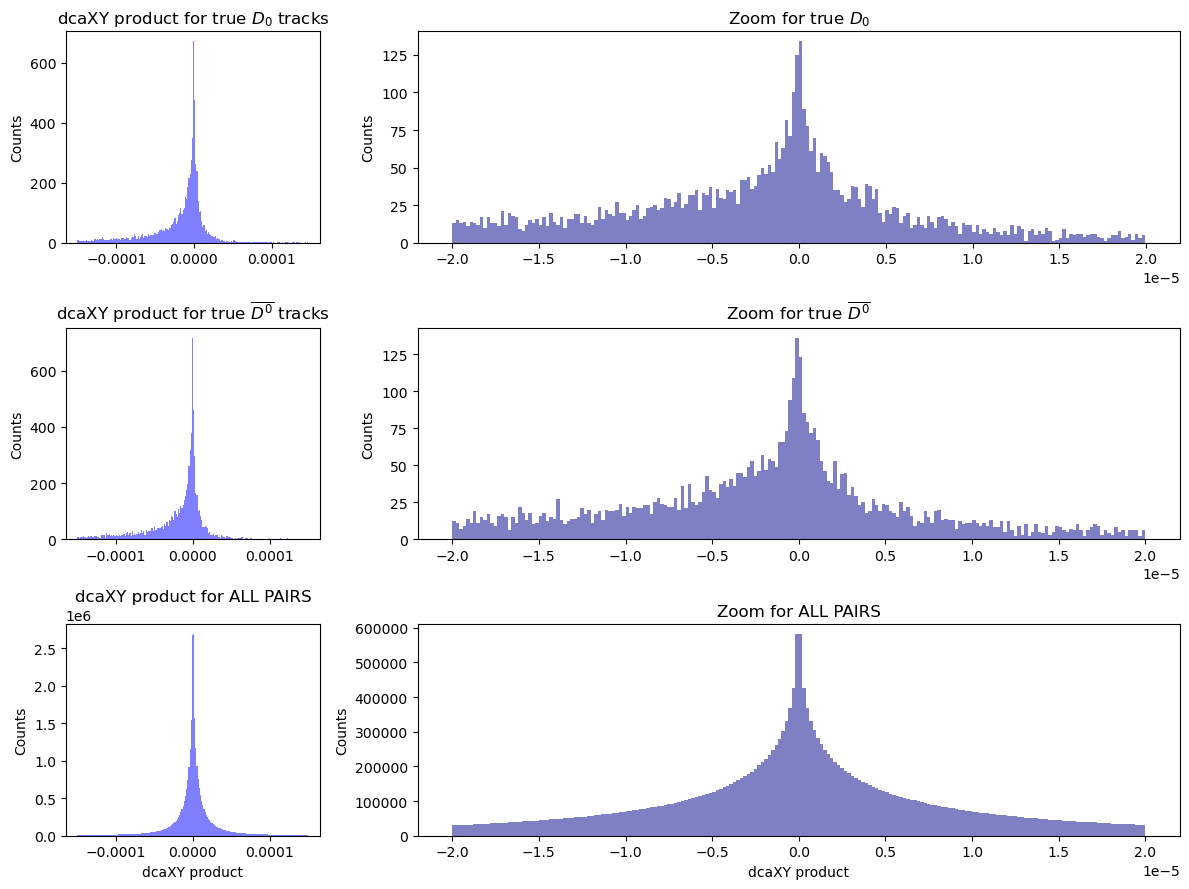

In [19]:
N_BINS = 200

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_anti_D0", "zoom_anti_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 9),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot dcaXY product FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("dcaXY product for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom for true $D_0$")

print(f"With the cut at {cut} we cut off {100-len(data)/d0_tot*100:.2f}% of original D0s")

# --- Plot dcaXY product FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_anti_D0"].set_ylabel("Counts")
axes["total_anti_D0"].set_title(r"dcaXY product for true $\overline{D^0}$ tracks")

# --- Zoom FOR TRUE anti_D0 ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_anti_D0"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
axes["zoom_anti_D0"].set_ylabel("Counts")
axes["zoom_anti_D0"].set_title(r"Zoom for true $\overline{D^0}$")

print(f"With the cut at {cut} we cut off {100-len(data)/anti_d0_tot*100:.2f}% of original anti-D0s")

# --- Plot dcaXY product FOR ALL PAIRS ---
data = final_results['dcaXY_product'].values
data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("dcaXY product")
axes["total_all"].set_title("dcaXY product for ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.00002
data = data[ (data > -cut) & (data < cut) ]
axes["zoom_all"].hist( data, bins=N_BINS, color="darkblue", alpha=0.5)
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("dcaXY product")
axes["zoom_all"].set_title("Zoom for ALL PAIRS")

print(f"With the cut at {cut} we cut off {100-len(data)/num_bg_pairs*100:.2f}% of background pairs")

plt.tight_layout()
plt.show()
del data

Best cut (external values): 0.000001
Signal kept: 89.45%  → Signal cut off: 10.55%
Background kept: 53.13%  → Background cut off: 46.87%


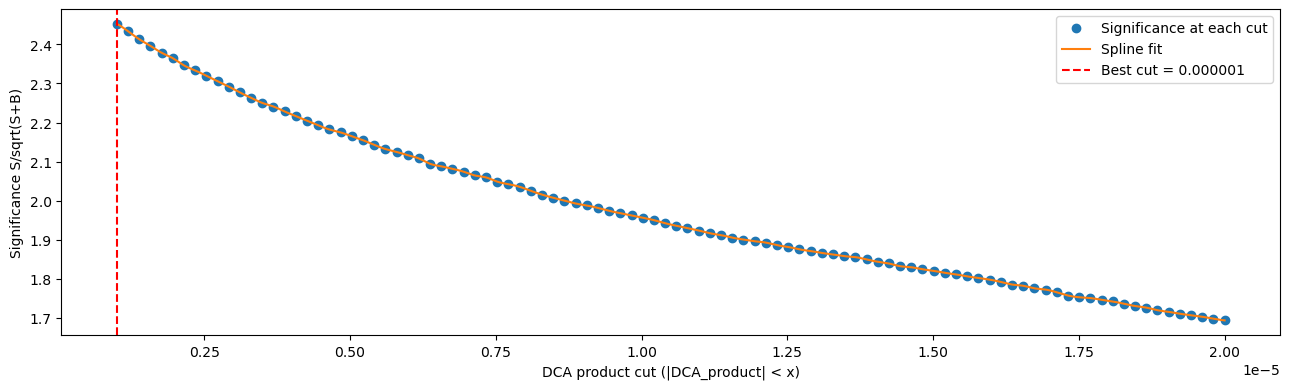

In [20]:
# SEARCH FOR BEST CUT IN DCA PRODUCT ANGLE:
x_val = np.linspace(0.000001, 0.00002, 100)
y_val =[]

signal_dca_prod = final_results.loc[ mask_signal, 'dcaXY_product'].values
background_dca_prod = final_results.loc[ mask_background, 'dcaXY_product'].values

for x in x_val:
    numerator = len( signal_dca_prod[ (signal_dca_prod<-x) | (signal_dca_prod>x) ] )
    denominator = len( background_dca_prod[ (background_dca_prod<-x) | (background_dca_prod>x) ] )
    y_val.append(numerator / np.sqrt(numerator + denominator))

# INTERPOLATION with spline:
spline = UnivariateSpline(x_val, y_val, s=0)
x_dense = np.linspace(min(x_val), max(x_val), 1000)
y_dense = spline(x_dense)               # computating the spline
best_cut = x_dense[np.argmax(y_dense)]

# PRINT results:
print(f"Best cut (external values): {best_cut:.6f}")
sig_eff = len(signal_dca_prod[(signal_dca_prod < -best_cut) | (signal_dca_prod > best_cut)]) / signal_tot
bg_eff  = len(background_dca_prod[(background_dca_prod < -best_cut) | (background_dca_prod < best_cut)]) / num_bg_pairs
print(f"Signal kept: {sig_eff*100:.2f}%  → Signal cut off: {(1-sig_eff)*100:.2f}%")
print(f"Background kept: {bg_eff*100:.2f}%  → Background cut off: {(1-bg_eff)*100:.2f}%")

# PLOT:
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(x_val, y_val, 'o', label='Significance at each cut')
ax.plot(x_dense, y_dense, '-', label='Spline fit')
ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.6f}')
ax.set_xlabel('DCA product cut (|DCA_product| < x)')
ax.set_ylabel('Significance S/sqrt(S+B)')
ax.legend()
plt.tight_layout()
plt.show()

Not very useful.

#### $p_T$ DISTRIBUTION

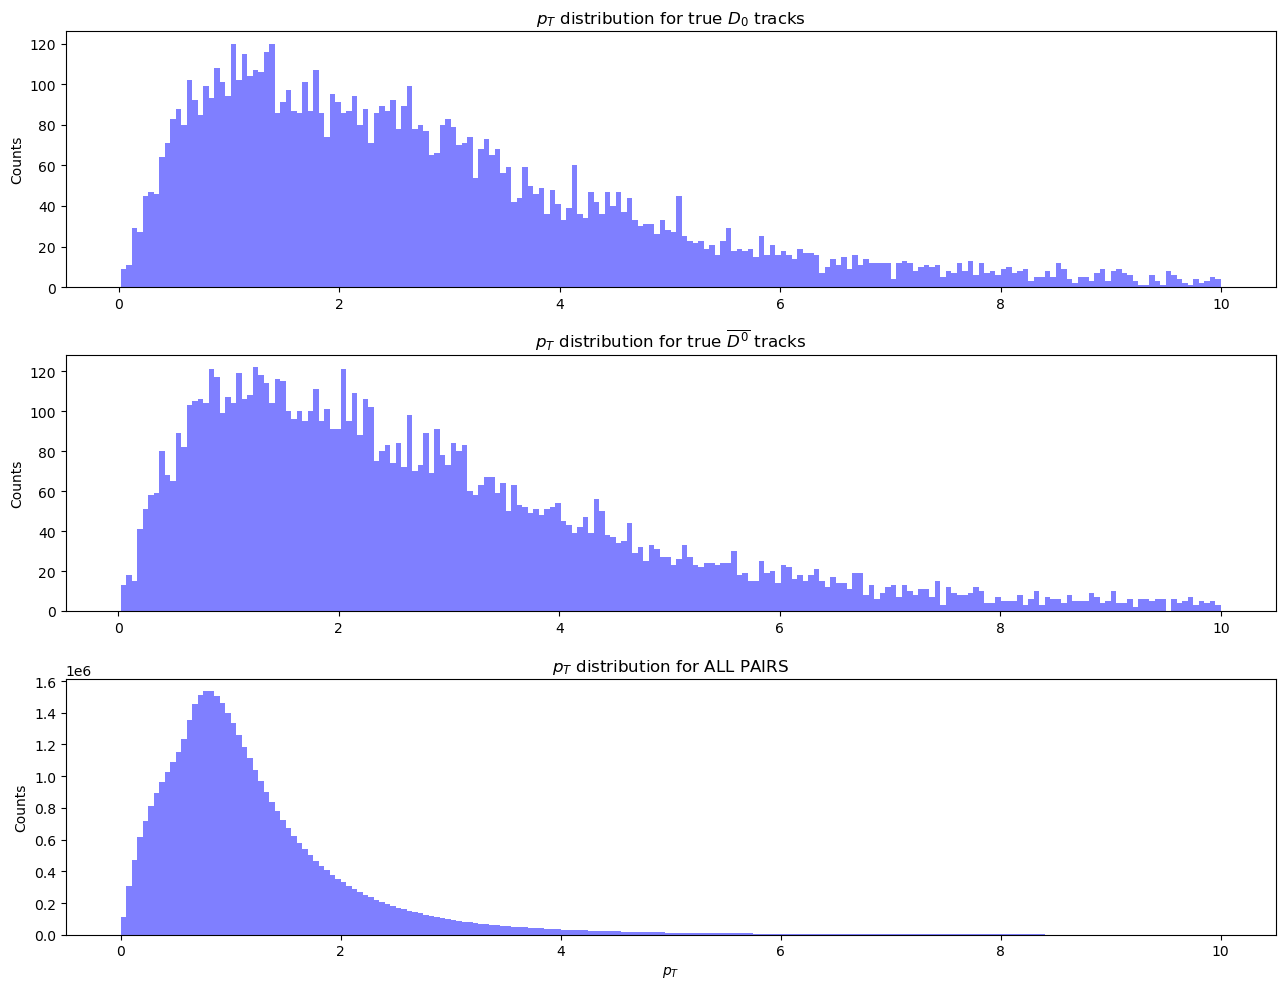

In [21]:
N_BINS = 200
fig, axs = plt.subplots(3, 1, figsize=(13, 10))

# --- pT for TRUE D0 ---
data = final_results.loc[mask_true_d0, 'pt'].values
data = data[data < 10]
axs[0].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[0].set_ylabel("Counts")
axs[0].set_title("$p_T$ distribution for true $D_0$ tracks")

# --- pT for TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'pt'].values
data = data[data < 10]
axs[1].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[1].set_ylabel("Counts")
axs[1].set_title(r"$p_T$ distribution for true $\overline{D^0}$ tracks")

# --- pT FOR ALL PAIRS ---
data = final_results['pt'].values
data = data[data < 10]
axs[2].hist(data, bins=N_BINS, color="blue", alpha=0.5)
axs[2].set_xlabel("$p_T$")
axs[2].set_ylabel("Counts")
axs[2].set_title("$p_T$ distribution for ALL PAIRS")

plt.tight_layout()
plt.show()
del data

The $p_T$ windows like $[2-4]$, $[3-6]$ or $[3-8]$ could be useful to find the signal.

#### DECAY LENGTH

With the cut at 0.05 we cut off 22.03% of original D0s
With the cut at 0.05 we cut off 21.94% of original anti-D0s
With the cut at 0.05 we cut off 43.37% of background pairs


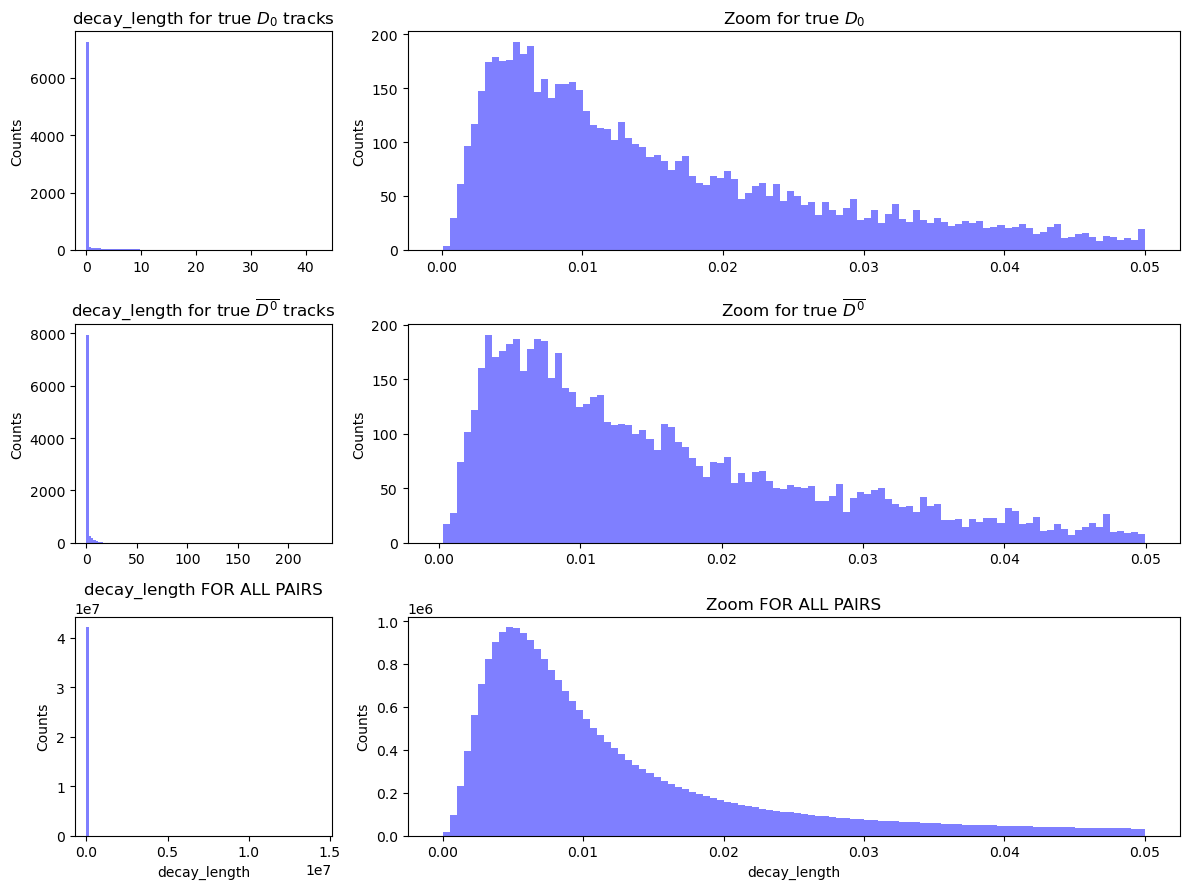

In [22]:
N_BINS = 100

# Layout con due colonne
zones = [
    ["total_D0", "zoom_D0"],
    ["total_anti_D0", "zoom_anti_D0"],
    ["total_all", "zoom_all"],
]

# Creazione della figura usando subplot_mosaic
fig, axes = plt.subplot_mosaic(
    zones,
    figsize=(12, 9),
    gridspec_kw={"width_ratios": [1, 3]}
)

# --- Plot decay length FOR TRUE D0 ---
data = final_results.loc[mask_true_d0, 'decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_D0"].set_ylabel("Counts")
axes["total_D0"].set_title("decay_length for true $D_0$ tracks")

# --- Zoom FOR TRUE D0 ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_D0"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_D0"].set_ylabel("Counts")
axes["zoom_D0"].set_title("Zoom for true $D_0$")

print(f"With the cut at {cut} we cut off {100-len(data)/d0_tot*100:.2f}% of original D0s")

# --- Plot decay length FOR TRUE anti_D0 ---
data = final_results.loc[mask_true_anti_d0, 'decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_anti_D0"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_anti_D0"].set_ylabel("Counts")
axes["total_anti_D0"].set_title(r"decay_length for true $\overline{{D^0}}$ tracks")

# --- Zoom FOR TRUE anti_D0 ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_anti_D0"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_anti_D0"].set_ylabel("Counts")
axes["zoom_anti_D0"].set_title(r"Zoom for true $\overline{{D^0}}$")

print(f"With the cut at {cut} we cut off {100-len(data)/anti_d0_tot*100:.2f}% of original anti-D0s")

# --- Plot decay length FOR ALL PAIRS ---
data = final_results['decay_length'].values
#data = data[ (data > -0.00015) & (data < 0.00015) ]
axes["total_all"].hist( data, bins=N_BINS, color="blue", alpha=0.5)
axes["total_all"].set_ylabel("Counts")
axes["total_all"].set_xlabel("decay_length")
axes["total_all"].set_title("decay_length FOR ALL PAIRS")

# --- Zoom FOR ALL PAIRS ---
cut = 0.05
data = data[ data < cut ]
axes["zoom_all"].hist( data, bins=100, color="blue", alpha=0.5)
axes["zoom_all"].set_ylabel("Counts")
axes["zoom_all"].set_xlabel("decay_length")
axes["zoom_all"].set_title("Zoom FOR ALL PAIRS")

print(f"With the cut at {cut} we cut off {100-len(data)/num_bg_pairs*100:.2f}% of background pairs")

plt.tight_layout()
plt.show()
del data

Best cut: decay_length > 0.0003
With the cut at 0.00, we keep 99.99% of the original signal
With the cut at 0.00, we keep 100.00% of the background pairs


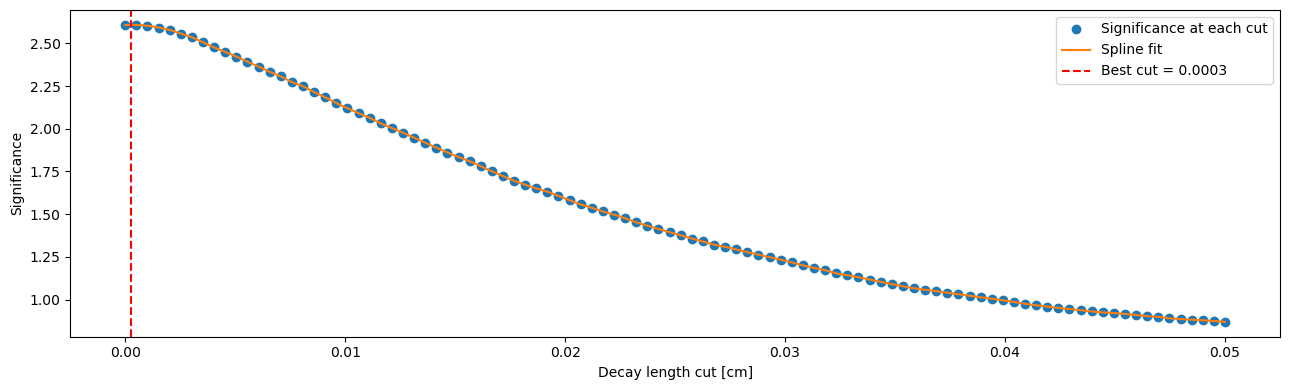

In [23]:
# --- RANGE OF CUTS ---
x_val = np.linspace(0, 0.05, 100)
y_val = []

# --- DATA ---
signal_dl = final_results.loc[mask_signal, 'decay_length'].values
background_dl = final_results.loc[mask_background, 'decay_length'].values

# --- SCAN ---
for x in x_val:
    numerator = len( signal_dl[ signal_dl > x ] )
    denominator = len( background_dl[ background_dl > x ] )
    if numerator + denominator > 0:
        y_val.append(numerator / np.sqrt(numerator + denominator))
    else:
        y_val.append(0)

# --- INTERPOLATION ---
spline = UnivariateSpline(x_val, y_val, s=0)
x_dense = np.linspace(min(x_val), max(x_val), 1000)
y_dense = spline(x_dense)
best_cut = x_dense[np.argmax(y_dense)]

# --- PRINT RESULTS ---
print(f"Best cut: decay_length > {best_cut:.4f}")
print(f"With the cut at {best_cut:.2f}, we keep {len(signal_dl[signal_dl > best_cut])/signal_tot*100:.2f}% of the original signal")
print(f"With the cut at {best_cut:.2f}, we keep {len(background_dl[background_dl > best_cut])/num_bg_pairs*100:.2f}% of the background pairs")

# --- PLOT ---
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(x_val, y_val, 'o', label='Significance at each cut')
ax.plot(x_dense, y_dense, '-', label='Spline fit')
ax.axvline(best_cut, color='r', linestyle='--', label=f'Best cut = {best_cut:.4f}')
ax.set_xlabel('Decay length cut [cm]')
ax.set_ylabel('Significance')
ax.legend()
plt.tight_layout()
plt.show()


Evidentemente anche se occhio sembra poterci essere un gain, non è significativo.

---

---

---

# TRYING CUTS

### CHOSEN CUTS

In [20]:
# single cuts:
cut_neg_TOFka = 7.3
cut_neg_TPCka = 2
cut_pos_TOFka = 7.8
cut_pos_TPCka = 1.8
cut_cos_pointing = 0.96


# we create the cuts as a mask:
cuts = (
    (
        ( (final_results['neg_TOFka'] > -cut_neg_TOFka) & (final_results['neg_TOFka'] < cut_neg_TOFka) &
          (final_results['neg_TPCka'] > -cut_pos_TOFka) & (final_results['neg_TPCka'] < cut_pos_TOFka) )
        |
        ( (final_results['pos_TOFka'] > -cut_pos_TOFka) & (final_results['pos_TOFka'] < cut_pos_TOFka) &
          (final_results['pos_TPCka'] > -cut_pos_TPCka) & (final_results['pos_TPCka'] < cut_pos_TPCka) )
    )
    &
    (final_results['cos_pointing'] > cut_cos_pointing) &
    # p_t window:
    (final_results['pt'] > 2) & (final_results['pt'] < 8)
)


### INVARIANT MASS PLOT

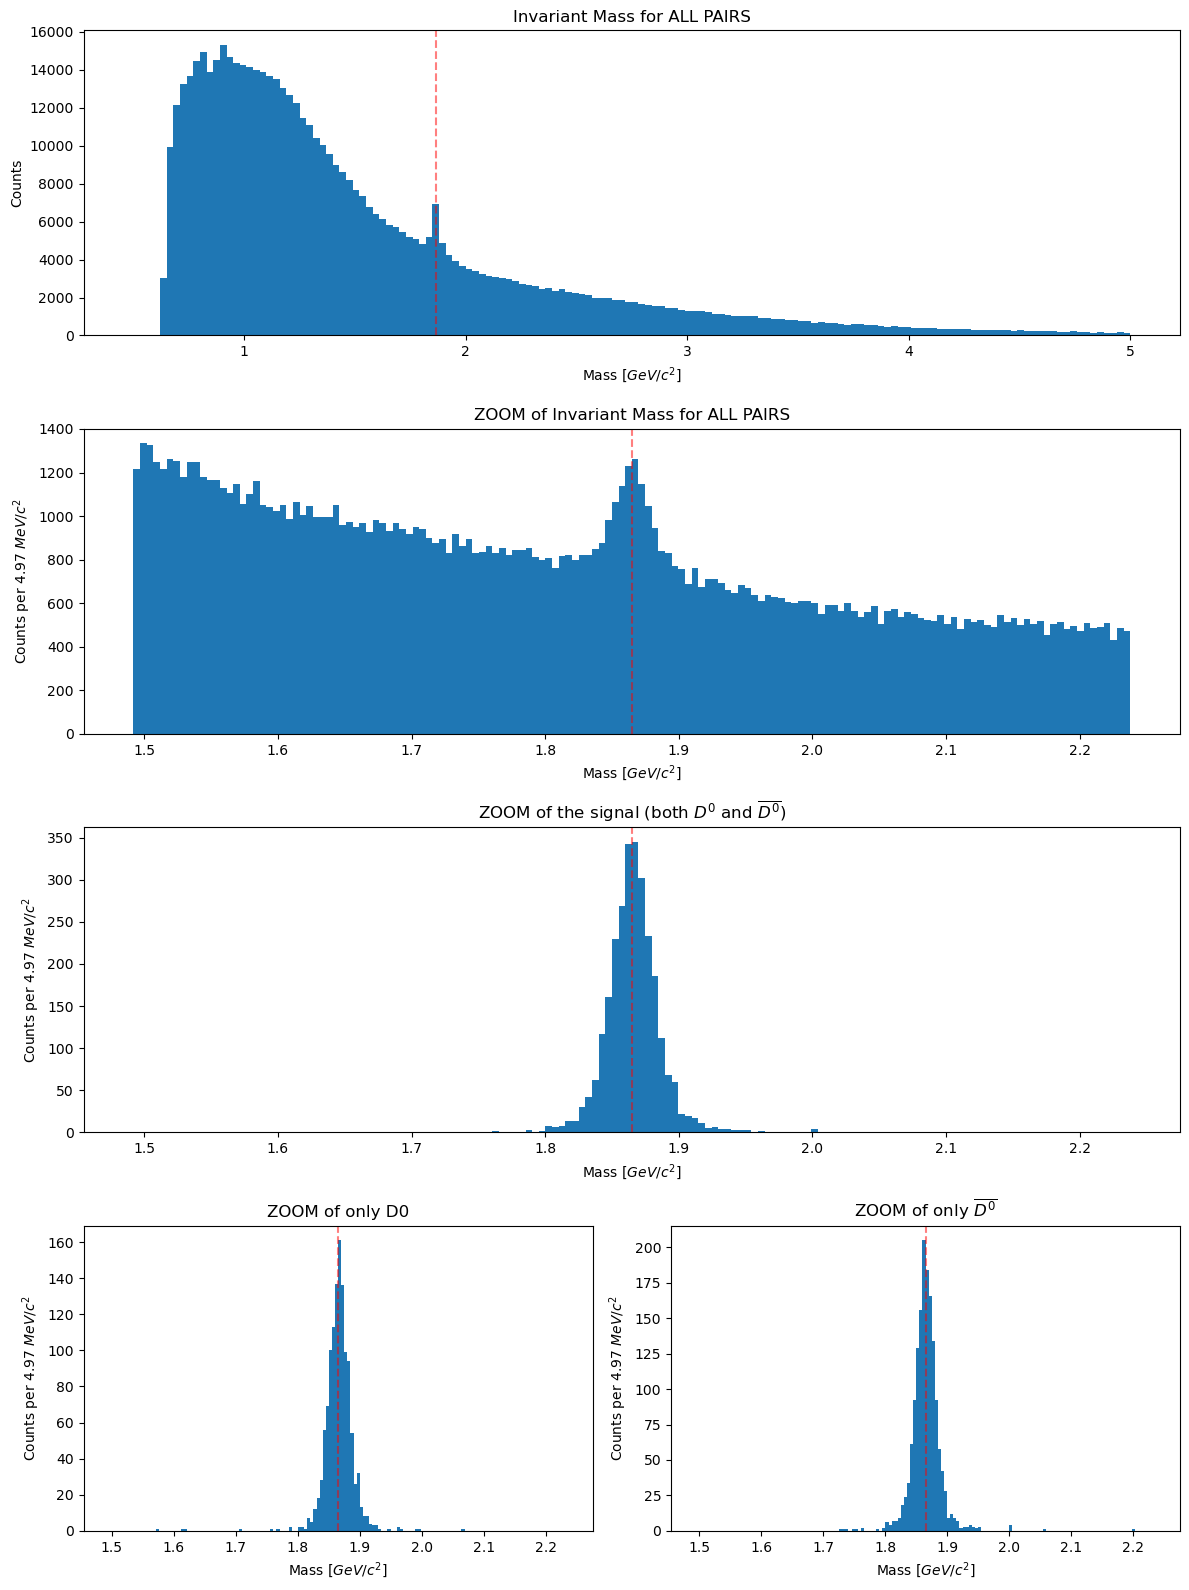

In [21]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0     # for zoom
N_BINS = 150

# Layout con due colonne
zones = [
    ["total", "total"],
    ["total_zoom", "total_zoom"],
    ["signal", "signal"],           # both D0 and anti_D0
    ["D0", "anti_D0"]
]

# Creazione della figura usando subplot_mosaic
fig, axs = plt.subplot_mosaic(
    zones,
    figsize=(12, 16),
    gridspec_kw={"width_ratios": [1, 1]}
)

# our cutted data with reflex component:---------------------------------
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
data = np.concatenate( [data_inv_mass, data_anti_mass] )

# PLOT OF ALL PAIRS
axs["total"].hist( data, bins=N_BINS, range=(0.5, 5))
axs["total"].axvline(x=m_d0, color="red", ls='--', alpha= 0.5)
axs["total"].set_xlabel("Mass [$GeV/c^2$]")
axs["total"].set_ylabel(f"Counts")
axs["total"].set_title("Invariant Mass for ALL PAIRS")

# ZOOM OF ALL PAIRS
axs["total_zoom"].hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["total_zoom"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["total_zoom"].set_xlabel("Mass [$GeV/c^2$]")
axs["total_zoom"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["total_zoom"].set_title("ZOOM of Invariant Mass for ALL PAIRS")

# out cutted and true D0 -------------------------------------------------
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )

# ZOOM OF the signal:
axs["signal"].hist( data, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["signal"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["signal"].set_xlabel("Mass [$GeV/c^2$]")
axs["signal"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["signal"].set_title("ZOOM of the signal (both $D^0$ and $\overline{{D^0}}$)")

# ZOOM OF only D0
axs["D0"].hist( data_inv_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["D0"].set_title("ZOOM of only D0")

# ZOOM OF only anti_D0
axs["anti_D0"].hist( data_anti_mass_true, bins=N_BINS, range=(MIN_MASS, MAX_MASS))
axs["anti_D0"].axvline(x=m_d0, color="red", ls='--', alpha=0.5)
axs["anti_D0"].set_xlabel("Mass [$GeV/c^2$]")
axs["anti_D0"].set_ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS)*1000:.2f} $MeV/c^2$")
axs["anti_D0"].set_title("ZOOM of only $\overline{{D^0}}$")

#plt.savefig("D0_Mass_MC.png")
plt.tight_layout()
plt.show()

#### INFO ON THE CUT

In [26]:
data_inv_bg  = final_results.loc[ mask_background & cuts, 'inv_mass'].values
data_anti_bg = final_results.loc[ mask_background & cuts, 'anti_mass'].values
data_bg = np.concatenate( [data_inv_bg, data_anti_bg] )

print(f"Total D0 before cuts:               {d0_tot}")
print(f"Total D0 found after cuts:          {len(data_inv_mass_true)} ---> {len(data_inv_mass_true)/d0_tot*100:.2f}% \n")
print(f"Total anti-D0 before cuts:          {anti_d0_tot}")
print(f"Total anti-D0 found after cuts:     {len(data_anti_mass_true)} ---> {len(data_anti_mass_true)/anti_d0_tot*100:.2f}% \n")
print(f"Total signal before cuts:           {signal_tot}")
print(f"Total signal found after cuts:      {len(data_inv_mass_true)+len(data_anti_mass_true)} ---> {(len(data_inv_mass_true)+len(data_anti_mass_true))/signal_tot*100:.2f}% \n")

print(f"Total background found after cuts:       ---> {len(data_bg)/num_bg_pairs*100:.2f}% \n")

# LET'S COUNT THE D0 INSIDE AN INTERVAL:
print(f"LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL): \n")
sigma_guess = 0.015
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
signal_filtered = signal[ (signal > m_d0 - 3*sigma_guess) & (signal < m_d0 + 3*sigma_guess) ]
# background:
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
bg = np.concatenate( [data_inv_mass, data_anti_mass] )
bg_filtered = bg[ (bg > m_d0 - 3*sigma_guess) & (bg < m_d0 + 3*sigma_guess) ]
print(f"Signal found in the interval:     {len(signal_filtered)}")
print(f"Background found in the interval: {len(bg_filtered)}\n")
print(f"Percentage of signal inside the interval: {len(signal_filtered)/ (len(bg_filtered) + len(signal_filtered) )*100:.2f}%")
print(f"Significance:                     {len(signal_filtered)/np.sqrt( len(bg_filtered)+ len(signal_filtered)):.2f}")
print(f"Ratio (signal/bg):                {len(signal_filtered)/len(bg_filtered):.2f}")

Total D0 before cuts:               8243
Total D0 found after cuts:          1217 ---> 14.76% 

Total anti-D0 before cuts:          8671
Total anti-D0 found after cuts:     1546 ---> 17.83% 

Total signal before cuts:           16914
Total signal found after cuts:      2763 ---> 16.34% 

Total background found after cuts:       ---> 1.33% 

LET'S CONCENTRATE ON A SINGLE INTERVAL AROUND D0 MASS (QUALITATIVE CONTROL): 

Signal found in the interval:     2615
Background found in the interval: 16947

Percentage of signal inside the interval: 13.37%
Significance:                     18.70
Ratio (signal/bg):                0.15


---

# FITTING MASS

We try to fit the invariant mass histogram using:
* a gaussian for the signal
* a gaussian for the reflex component
* a linear function for the background

We do it in a way so that the ratio $N_1/N_2$ between the two gaussian is fixed, and the parameter $k$ is free:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Reflex} + \text{Signal} \right) + \text{Background}
$$

which means:
$$
\text{Fit Function} = k \cdot \left( \frac{N_1}{N_2} \text{Gaussian1} + \text{Gaussian2} \right) + a \cdot x +b
$$

#### FINDING RATIO $N_1/N_2$
Let's fit the data given by signal + reflex component (using MC info).

Ratio (reflex/sign): 0.7721821047493508


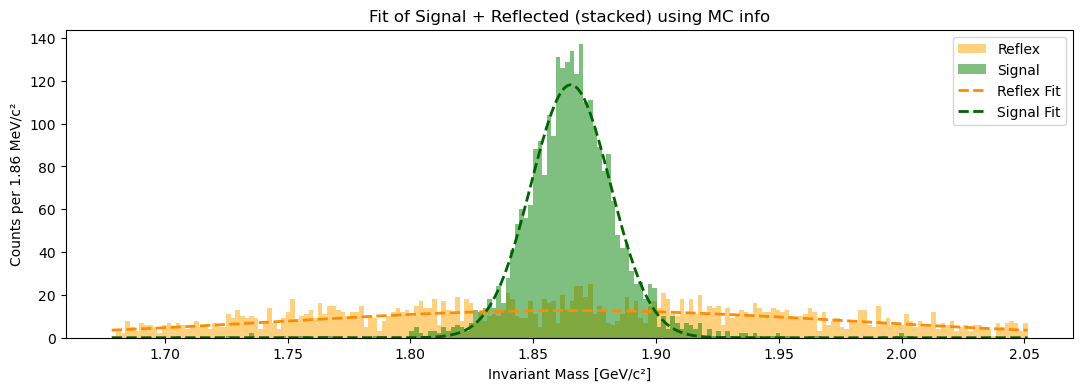

In [27]:
# --- Fit function: double Gaussian---
def fit_gauss_mc(x, k, mu1, sigma1):
    return k * norm.pdf(x, loc=mu1, scale=sigma1) 

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 200
binsize = (MAX_MASS - MIN_MASS)/N_BINS
# --- Initial parameter guesses ---
k_param = 100
gauss_params = [m_d0, 0.05]

# Histogram of signal and rflected part data only
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & cuts, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & cuts, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
# Stacked histogram
fig, ax = plt.subplots(figsize=(13,4))

# HISTOGRAM:
# ------- reflex component:
reflex_counts, reflex_edges, _ = ax.hist(reflex_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Reflex', color='orange')
reflex_centers = (reflex_edges[:-1] + reflex_edges[1:]) / 2.0
# poisson errors:
sigma_reflex_hist = np.sqrt(reflex_counts)
sigma_reflex_hist = np.clip(sigma_reflex_hist, 1, None)  # avoid zeros
# ------- signal:
sign_counts, sign_edges, _ = ax.hist(signal_data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Signal', color='green')
sign_centers = (sign_edges[:-1] + sign_edges[1:]) / 2.0
# poisson errors:
sigma_sign_hist = np.sqrt(sign_counts)
sigma_sign_hist = np.clip(sigma_sign_hist, 1, None)  # avoid zeros

# FIT:
sign_fit_res = curve_fit( fit_gauss_mc, xdata = sign_centers, ydata = sign_counts, sigma = sigma_sign_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
sign_params = sign_fit_res[0]
mu_sign, sigma_sign = sign_params[1], sign_params[2]
k_sign = sign_params[0]
# ----
reflex_fit_res = curve_fit( fit_gauss_mc, xdata = reflex_centers, ydata = reflex_counts, sigma = sigma_reflex_hist,
                            p0 = [k_param, 
                                  gauss_params[0], gauss_params[1]
                                 ]
                        )
reflex_params = reflex_fit_res[0]
mu_reflex, sigma_reflex = reflex_params[1], reflex_params[2]
k_reflex = reflex_params[0]

# PRINT:
ratio_from_fit = k_reflex/k_sign
print(f"Ratio (reflex/sign): {ratio_from_fit}")

# PLOT of fitted curves:
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, fit_gauss_mc(x_fit, k_reflex, mu_reflex, sigma_reflex), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, fit_gauss_mc(x_fit, k_sign, mu_sign, sigma_sign), '--', color='darkgreen', linewidth=2, label='Signal Fit')


ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Fit of Signal + Reflected (stacked) using MC info")
ax.legend()
plt.show()

#### INVARIANT MASS FIT

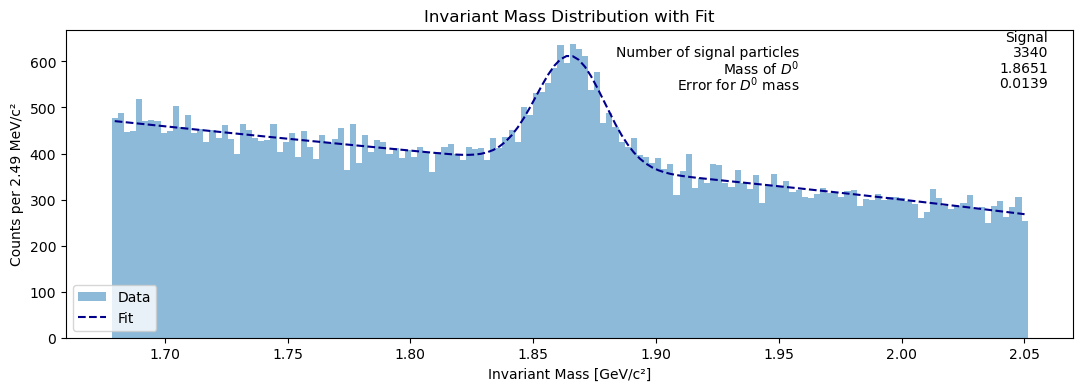

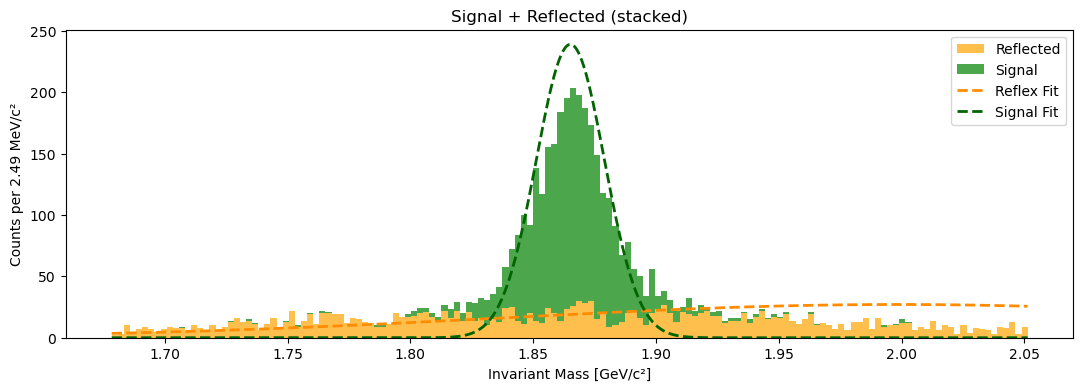

Results of signal fit: D0 mass  1.865127        error 0.013866
Results of reflex fit: center   1.998732        error 0.158476
Ratio N1/N2: 0.933155


In [30]:
# --- Fit function: double Gaussian + linear background ---
ratio =  ratio_from_fit   # fixed ratio between Gaussians
def fit_function(x, k, mu1, sigma1, mu2, sigma2, a, b):
    return k * (ratio*norm.pdf(x, loc=mu1, scale=sigma1) + norm.pdf(x, loc=mu2, scale=sigma2)) + a*x + b

# INITIALIZATIONS:
MIN_MASS, MAX_MASS = 0.9*m_d0, 1.1*m_d0
N_BINS = 150
binsize = (MAX_MASS - MIN_MASS)/N_BINS
# --- Initial parameter guesses ---
k_param = 100
signal_params = [m_d0, 0.02]
mirror_params = [m_d0, 0.1]
back_params   = [133, 1000]
# --- Data ---
data_inv_mass  = final_results.loc[cuts, 'inv_mass'].values
data_anti_mass = final_results.loc[cuts, 'anti_mass'].values
data = np.concatenate([data_inv_mass, data_anti_mass])

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
both_counts, both_edges, _ = ax.hist(data, bins=N_BINS, range=(MIN_MASS, MAX_MASS), alpha=0.5, label='Data')
both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
# --- Poisson errors ---
sigma_hist = np.sqrt(both_counts)
sigma_hist = np.clip(sigma_hist, 1, None)  # avoid zeros

# FIT:
both_fit_res = curve_fit( f = fit_function, xdata = both_centers, ydata = both_counts, sigma = sigma_hist,
                            p0 = [k_param, 
                                  signal_params[0], signal_params[1],
                                  mirror_params[0], mirror_params[1],
                                  back_params[0], back_params[1]
                                 ]
                        )
both_params = both_fit_res[0]
mu1, sigma1 = both_params[1], both_params[2]
mu2, sigma2 = both_params[3], both_params[4]
k_fit = both_params[0]

# PLOT of fitted curve:
ax.plot(
    both_centers,
    fit_function( both_centers, both_params[0], both_params[1], both_params[2],
        both_params[3], both_params[4], both_params[5], both_params[6]
    ),
    color='darkblue', linestyle='dashed', linewidth=1.5, label='Fit'
)

# COUNT of D0:
mass_from_fit = both_params[1]
sigma_from_fit = both_params[2]
counts_from_fit = both_params[0] * ratio * (norm.cdf(MAX_MASS, loc=mu1, scale=sigma1) - norm.cdf(MIN_MASS, loc=mu1, scale=sigma1)) /binsize

# TABLE INSIDE PLOT:
ax.table(
    cellText = [[f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"]],
    rowLabels = [r'Number of signal particles', r'Mass of $D^0$', r'Error for $D^0$ mass'],
    colLabels = ['Signal'],
    colLoc = "right",
    bbox = [0.75, 0.8, 0.25, 0.2],
    edges = 'open',
    rowLoc = 'right'
)

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Invariant Mass Distribution with Fit")
ax.legend(loc='lower left') 
plt.show()

# -------------------------------------------------------------------------------------------------------------

# SECOND PLOT: signal and reflected plot with two Gaussians
fig, ax = plt.subplots(figsize=(13,4))

# Histogram of signal and rflected part data only
# reflected part:
data_inv_mass_true_ref   = final_results.loc[ mask_true_d0 & cuts, 'anti_mass'].values
data_anti_mass_true_ref  = final_results.loc[ mask_true_anti_d0 & cuts, 'inv_mass'].values
reflex_data = np.concatenate( [ data_inv_mass_true_ref, data_anti_mass_true_ref] )
# signal:
data_inv_mass_true   = final_results.loc[ mask_true_d0 & cuts, 'inv_mass'].values
data_anti_mass_true  = final_results.loc[ mask_true_anti_d0 & cuts, 'anti_mass'].values
signal_data = np.concatenate( [ data_inv_mass_true, data_anti_mass_true] )
# Stacked histogram
ax.hist([reflex_data, signal_data], bins=N_BINS, range=(MIN_MASS, MAX_MASS),
        stacked=True, color=['orange', 'green'], alpha=0.7,
        label=['Reflected', 'Signal'])

# Fitted Gaussians
x_fit = np.linspace(MIN_MASS, MAX_MASS, 1000)
ax.plot(x_fit, k_fit*norm.pdf(x_fit, loc=mu2, scale=sigma2), '--', color='darkorange', linewidth=2, label='Reflex Fit')
ax.plot(x_fit, k_fit*ratio*norm.pdf(x_fit, loc=mu1, scale=sigma1), '--', color='darkgreen', linewidth=2, label='Signal Fit')

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Signal + Reflected (stacked)")
ax.legend()
plt.show()

print(f"Results of signal fit: D0 mass  {mass_from_fit:3f}        error {sigma_from_fit:3f}")
print(f"Results of reflex fit: center   {mu2:3f}        error {sigma2:3f}")
print(f"Ratio N1/N2: {mu1/mu2:3f}")

In [31]:
print(f"True number of signal particles:     {len(signal_filtered)}")
print(f"Expected number of signal particles: {counts_from_fit:.0f}")

True number of signal particles:     2615
Expected number of signal particles: 3340
